
--- Simulating Regime: Ciclo Limite (Critical Regime) ---
Forma de t: (20000,)
Forma de E_signal: (20000,)
Forma de I_signal: (20000,)
Primeros 10 valores de E_signal: [0.1012141  0.10184133 0.10308847 0.10436347 0.10585357 0.1078667
 0.11095056 0.11447565 0.11873216 0.12266942]
Últimos 10 valores de E_signal: [0.36004399 0.3591464  0.35865755 0.35776772 0.35637328 0.354611
 0.3531429  0.35128279 0.3498288  0.34817837]
Min/Max/Mean de E_signal: -0.4568 / 0.8565 / 0.3666
Primeros 10 valores de I_signal: [0.09935249 0.09860953 0.09699533 0.09576264 0.09451344 0.09292743
 0.09148226 0.08987352 0.0875494  0.08574954]
Últimos 10 valores de I_signal: [0.44437549 0.4410787  0.43742833 0.43394658 0.43044925 0.42713215
 0.42392242 0.4211343  0.4179353  0.4149701 ]
Min/Max/Mean de I_signal: -0.4424 / 0.8130 / 0.2626


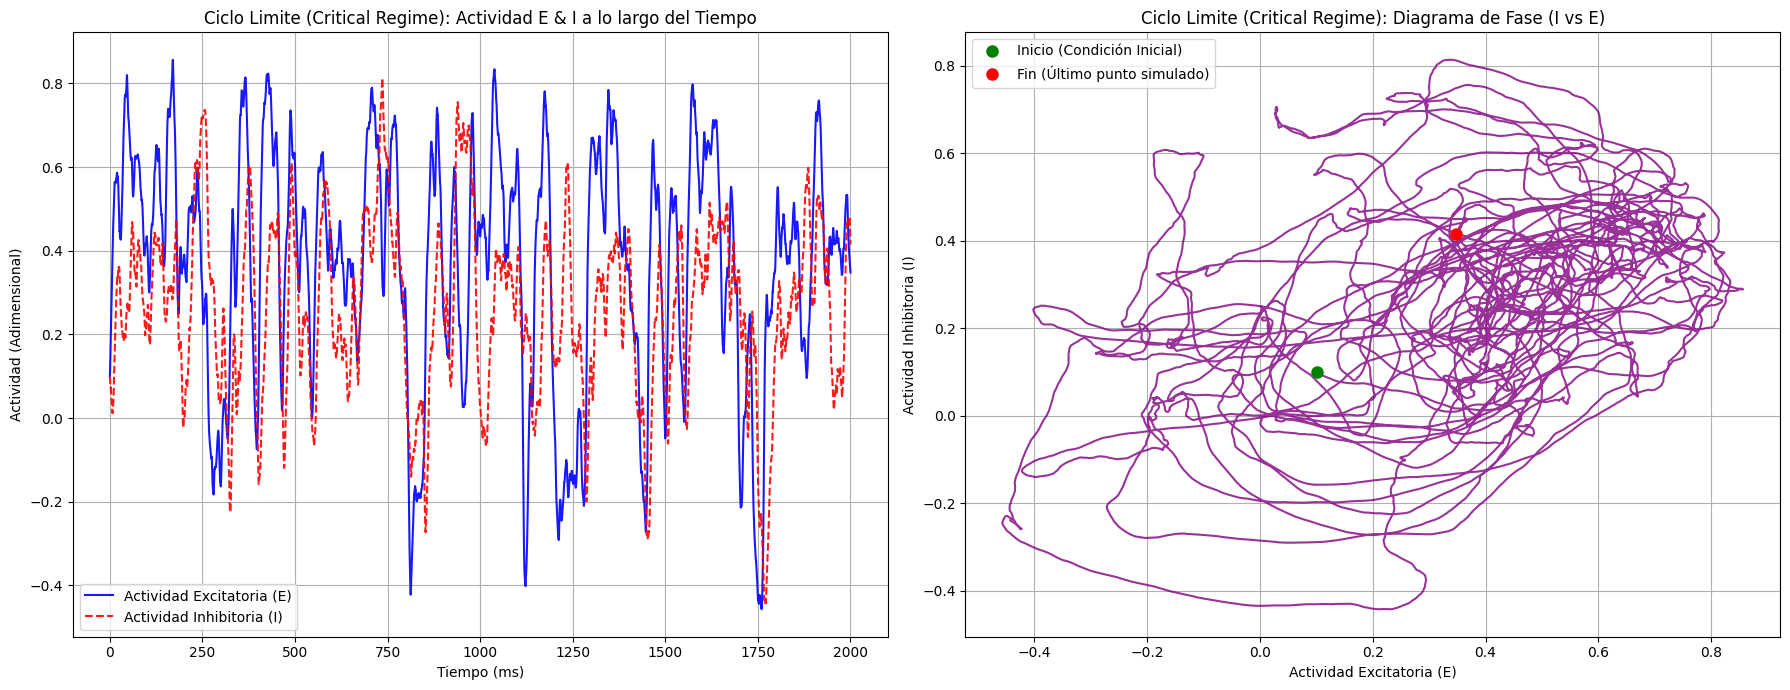

  Ciclo Limite (Critical Regime) simulation completed.

--- Observaciones ---
Si los gráficos muestran **oscilaciones sostenidas** y el diagrama de fase dibuja un **bucle cerrado estable**,
has encontrado un **Ciclo Límite**. Esto indica un comportamiento rítmico del nodo neuronal.

--- ¿Quieres explorar otros regímenes? ---
Puedes modificar `params['exc_ext']` para buscar:
  - **Nodo Estable (baja actividad):** `model.params['exc_ext'] = 0.30` (verás una convergencia a un punto bajo).
  - **Nodo Estable (alta actividad):** `model.params['exc_ext'] = 0.90` (verás una convergencia a un punto alto).
  - **Foco Estable (oscilaciones amortiguadas):** `model.params['exc_ext'] = 0.50` o `0.70` (verás una espiral que se asienta en un punto).


In [2]:
import neurolib.models.wc as wc
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración de la Simulación ---
duration = 20000  # ms (5 segundos para ver bien las oscilaciones)
dt = 0.1         # ms (Paso de tiempo)

# --- Definición de Parámetros para un Régimen de Ciclo Límite ---
regime_name = "Ciclo Limite (Critical Regime)"
params = {
    'exc_ext': 0.68,  # Ligeramente ajustado para intentar una actividad más visible
    'sigma_ou': 0.15, # Ligeramente ajustado para más ruido si es necesario
    'plot_xlim_start': duration - 1000,
    'plot_xlim_end': duration
}

# Otros parámetros del modelo Wilson-Cowan (constantes)
common_wc_params = {
    'a_exc': 1.0,
    'mu_exc': 2.0,
    'a_inh': 1.0,
    'mu_inh': 4.0,
    'tau_exc': 10.0,
    'tau_inh': 10.0,
    'c_excexc': 12.0,
    'c_excinh': 10.0,
    'c_inhexc': 10.0,
    'c_inhinh': 2.0,
    'tau_ou': 10.0,
    'exc_ou_mean': 0.0,
    'inh_ou_mean': 0.0,
    'exc_init': np.array([[0.1]]),
    'inh_init': np.array([[0.1]])
}

print(f"\n--- Simulating Regime: {regime_name} ---")

# --- 1. Crear e Instanciar el Modelo ---
model = wc.WCModel()
model.duration = duration
model.dt = dt

# Asignar parámetros específicos y comunes al modelo
model.params['exc_ext'] = params['exc_ext']
model.params['sigma_ou'] = params['sigma_ou']
for p_name, p_val in common_wc_params.items():
    model.params[p_name] = p_val

# --- 2. Ejecutar la Simulación ---
model.run()

# --- 3. Extraer las señales ---
time = model.outputs["t"]
E_signal = model.outputs["exc"][0]
I_signal = model.outputs["inh"][0]

# --- DEPURACIÓN: Verificar formas, primeros/últimos valores, y rango ---
print(f"Forma de t: {time.shape}")
print(f"Forma de E_signal: {E_signal.shape}")
print(f"Forma de I_signal: {I_signal.shape}")
print(f"Primeros 10 valores de E_signal: {E_signal[:10]}")
print(f"Últimos 10 valores de E_signal: {E_signal[-10:]}")
print(f"Min/Max/Mean de E_signal: {np.min(E_signal):.4f} / {np.max(E_signal):.4f} / {np.mean(E_signal):.4f}")
print(f"Primeros 10 valores de I_signal: {I_signal[:10]}")
print(f"Últimos 10 valores de I_signal: {I_signal[-10:]}")
print(f"Min/Max/Mean de I_signal: {np.min(I_signal):.4f} / {np.max(I_signal):.4f} / {np.mean(I_signal):.4f}")


# --- 4. Plotear las señales E e I a lo largo del tiempo y el Diagrama de Fase ---
plt.figure(figsize=(18, 7))

# Subplot 1: Actividad Excitatoria e Inhibitoria en el Tiempo
plt.subplot(1, 2, 1)
plt.plot(time, E_signal, label='Actividad Excitatoria (E)', color='blue', alpha=0.9)
plt.plot(time, I_signal, label='Actividad Inhibitoria (I)', color='red', linestyle='--', alpha=0.9)
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad (Adimensional)')
plt.title(f'{regime_name}: Actividad E & I a lo largo del Tiempo')
plt.legend()
plt.grid(True)
# plt.xlim(params['plot_xlim_start'], params['plot_xlim_end']) # Comentado temporalmente para ver todo el rango

# Subplot 2: Diagrama de Fase (I vs E)
plt.subplot(1, 2, 2)
plt.plot(E_signal, I_signal, color='purple', linewidth=1.5, alpha=0.8)

plt.plot(E_signal[0], I_signal[0], 'go', markersize=8, label='Inicio (Condición Inicial)')
plt.plot(E_signal[-1], I_signal[-1], 'ro', markersize=8, label='Fin (Último punto simulado)')

plt.xlabel('Actividad Excitatoria (E)')
plt.ylabel('Actividad Inhibitoria (I)')
plt.title(f'{regime_name}: Diagrama de Fase (I vs E)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"  {regime_name} simulation completed.")
print("\n--- Observaciones ---")
print("Si los gráficos muestran **oscilaciones sostenidas** y el diagrama de fase dibuja un **bucle cerrado estable**,")
print("has encontrado un **Ciclo Límite**. Esto indica un comportamiento rítmico del nodo neuronal.")
print("\n--- ¿Quieres explorar otros regímenes? ---")
print("Puedes modificar `params['exc_ext']` para buscar:")
print("  - **Nodo Estable (baja actividad):** `model.params['exc_ext'] = 0.30` (verás una convergencia a un punto bajo).")
print("  - **Nodo Estable (alta actividad):** `model.params['exc_ext'] = 0.90` (verás una convergencia a un punto alto).")
print("  - **Foco Estable (oscilaciones amortiguadas):** `model.params['exc_ext'] = 0.50` o `0.70` (verás una espiral que se asienta en un punto).")


--- Simulating Regime: Ciclo Limite (Critical Regime - Menos Ruido) ---
Forma de t: (20000,)
Forma de E_signal: (20000,)
Forma de I_signal: (20000,)
Primeros 10 valores de E_signal: [0.1011644  0.10238812 0.10366974 0.10494314 0.10622899 0.10757149
 0.10892305 0.11029608 0.11169229 0.11308215]
Últimos 10 valores de E_signal: [0.41927263 0.41915167 0.41904818 0.41895505 0.41886916 0.41878362
 0.41870565 0.41864118 0.41859987 0.41858132]
Min/Max/Mean de E_signal: 0.1012 / 0.4489 / 0.4034
Primeros 10 valores de I_signal: [0.09935249 0.09872655 0.09810126 0.09755168 0.09700387 0.09650396
 0.0960407  0.09561915 0.09524793 0.09484621]
Últimos 10 valores de I_signal: [0.28758709 0.28791836 0.28823873 0.28857728 0.28889918 0.28919529
 0.28948227 0.28981437 0.29009822 0.29034827]
Min/Max/Mean de I_signal: 0.0848 / 0.3072 / 0.2727


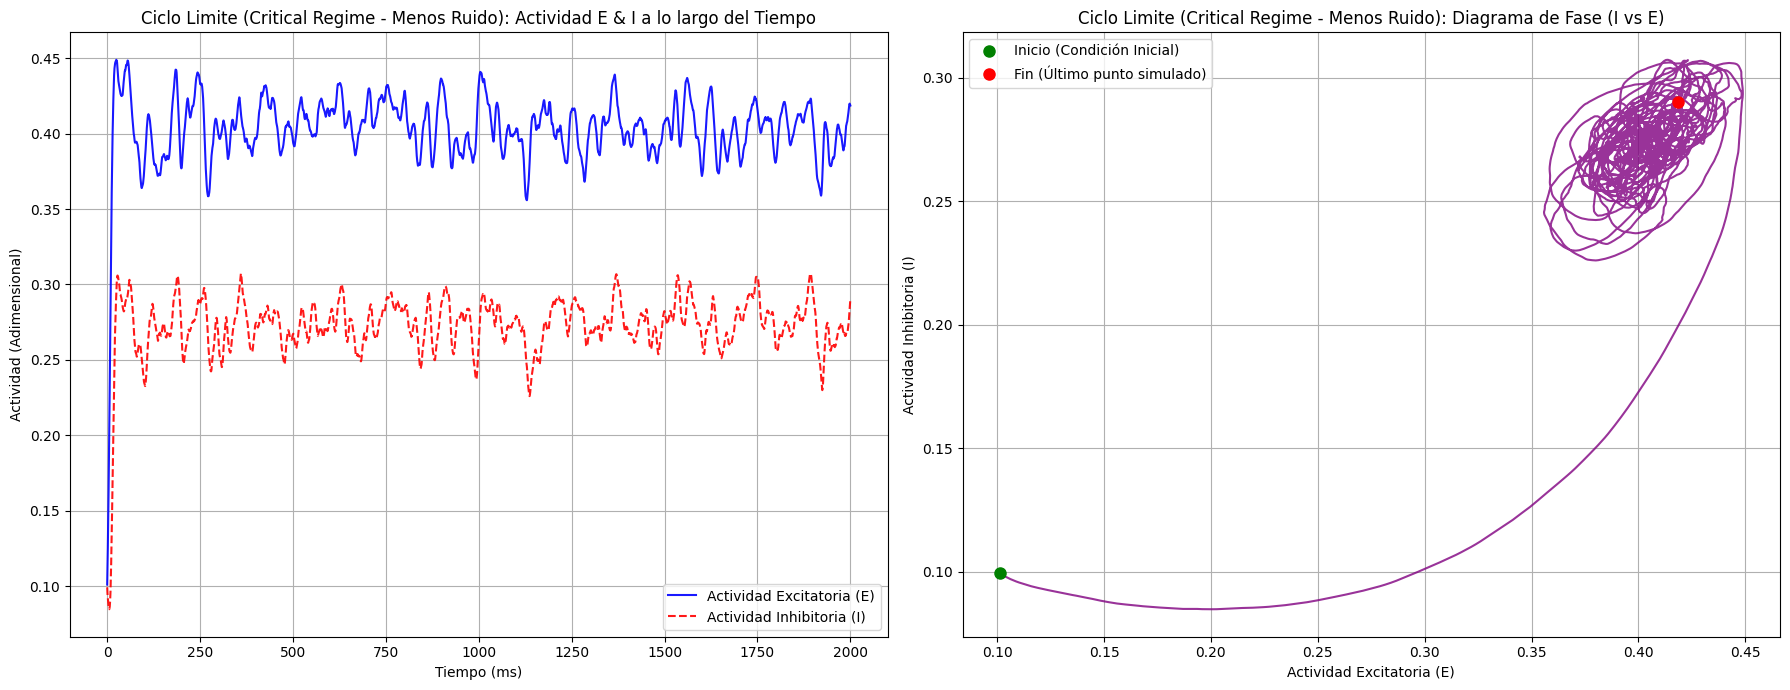

  Ciclo Limite (Critical Regime - Menos Ruido) simulation completed.

--- Observaciones ---
Al reducir la intensidad del ruido (`sigma_ou`), la trayectoria del ciclo límite debería verse mucho más **limpia y definida**.
Las oscilaciones en la señal de tiempo también deberían parecer más regulares.

--- Próximos pasos para explorar ---
Si el ciclo límite aún no es perfectamente nítido, puedes intentar:
  - Reducir `sigma_ou` aún más (por ejemplo, a `0.005` o incluso `0.0`).
  - Ajustar ligeramente `exc_ext` (por ejemplo, `0.60` o `0.70`) para ver si el ciclo se vuelve más 'fuerte'.
  - Aumentar la `duration` de la simulación para permitir que el sistema se asiente completamente en el ciclo.


In [3]:
import neurolib.models.wc as wc
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración de la Simulación ---
duration = 40000  # ms (5 segundos para ver bien las oscilaciones)
dt = 0.1         # ms (Paso de tiempo)

# --- Definición de Parámetros para un Régimen de Ciclo Límite con MENOS RUIDO ---
regime_name = "Ciclo Limite (Critical Regime - Menos Ruido)"
params = {
    'exc_ext': 0.65,  # Mantenemos un valor intermedio para el ciclo límite
    'sigma_ou': 0.01, # ¡Clave! Reducimos drásticamente la intensidad del ruido
    'plot_xlim_start': duration - 1000,
    'plot_xlim_end': duration
}

# Otros parámetros del modelo Wilson-Cowan (constantes)
common_wc_params = {
    'a_exc': 1.0,
    'mu_exc': 2.0,
    'a_inh': 1.0,
    'mu_inh': 4.0,
    'tau_exc': 10.0,
    'tau_inh': 10.0,
    'c_excexc': 12.0,
    'c_excinh': 10.0,
    'c_inhexc': 10.0,
    'c_inhinh': 2.0,
    'tau_ou': 10.0,   # Constante de tiempo del ruido (puedes ajustarla también, pero sigma_ou es más directo)
    'exc_ou_mean': 0.0,
    'inh_ou_mean': 0.0,
    'exc_init': np.array([[0.1]]),
    'inh_init': np.array([[0.1]])
}

print(f"\n--- Simulating Regime: {regime_name} ---")

# --- 1. Crear e Instanciar el Modelo ---
model = wc.WCModel()
model.duration = duration
model.dt = dt

# Asignar parámetros específicos y comunes al modelo
model.params['exc_ext'] = params['exc_ext']
model.params['sigma_ou'] = params['sigma_ou'] # Aquí se aplica el nuevo (reducido) ruido
for p_name, p_val in common_wc_params.items():
    model.params[p_name] = p_val

# --- 2. Ejecutar la Simulación ---
model.run()

# --- 3. Extraer las señales ---
time = model.outputs["t"]
E_signal = model.outputs["exc"][0]
I_signal = model.outputs["inh"][0]

# --- DEPURACIÓN: Verificar formas, primeros/últimos valores, y rango ---
print(f"Forma de t: {time.shape}")
print(f"Forma de E_signal: {E_signal.shape}")
print(f"Forma de I_signal: {I_signal.shape}")
print(f"Primeros 10 valores de E_signal: {E_signal[:10]}")
print(f"Últimos 10 valores de E_signal: {E_signal[-10:]}")
print(f"Min/Max/Mean de E_signal: {np.min(E_signal):.4f} / {np.max(E_signal):.4f} / {np.mean(E_signal):.4f}")
print(f"Primeros 10 valores de I_signal: {I_signal[:10]}")
print(f"Últimos 10 valores de I_signal: {I_signal[-10:]}")
print(f"Min/Max/Mean de I_signal: {np.min(I_signal):.4f} / {np.max(I_signal):.4f} / {np.mean(I_signal):.4f}")


# --- 4. Plotear las señales E e I a lo largo del tiempo y el Diagrama de Fase ---
plt.figure(figsize=(18, 7))

# Subplot 1: Actividad Excitatoria e Inhibitoria en el Tiempo
plt.subplot(1, 2, 1)
plt.plot(time, E_signal, label='Actividad Excitatoria (E)', color='blue', alpha=0.9)
plt.plot(time, I_signal, label='Actividad Inhibitoria (I)', color='red', linestyle='--', alpha=0.9)
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad (Adimensional)')
plt.title(f'{regime_name}: Actividad E & I a lo largo del Tiempo')
plt.legend()
plt.grid(True)
# plt.xlim(params['plot_xlim_start'], params['plot_xlim_end']) # Comentado temporalmente para ver todo el rango

# Subplot 2: Diagrama de Fase (I vs E)
plt.subplot(1, 2, 2)
plt.plot(E_signal, I_signal, color='purple', linewidth=1.5, alpha=0.8)

plt.plot(E_signal[0], I_signal[0], 'go', markersize=8, label='Inicio (Condición Inicial)')
plt.plot(E_signal[-1], I_signal[-1], 'ro', markersize=8, label='Fin (Último punto simulado)')

plt.xlabel('Actividad Excitatoria (E)')
plt.ylabel('Actividad Inhibitoria (I)')
plt.title(f'{regime_name}: Diagrama de Fase (I vs E)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"  {regime_name} simulation completed.")
print("\n--- Observaciones ---")
print("Al reducir la intensidad del ruido (`sigma_ou`), la trayectoria del ciclo límite debería verse mucho más **limpia y definida**.")
print("Las oscilaciones en la señal de tiempo también deberían parecer más regulares.")

print("\n--- Próximos pasos para explorar ---")
print("Si el ciclo límite aún no es perfectamente nítido, puedes intentar:")
print("  - Reducir `sigma_ou` aún más (por ejemplo, a `0.005` o incluso `0.0`).")
print("  - Ajustar ligeramente `exc_ext` (por ejemplo, `0.60` o `0.70`) para ver si el ciclo se vuelve más 'fuerte'.")
print("  - Aumentar la `duration` de la simulación para permitir que el sistema se asiente completamente en el ciclo.")


--- Simulating Regime: Ciclo Limite (Critical Regime - Menos Ruido) - ALTA AMPLITUD ---
Forma de t: (20000,)
Forma de E_signal: (20000,)
Forma de I_signal: (20000,)
Primeros 10 valores de E_signal: [0.10412592 0.10833578 0.11262507 0.11693829 0.12127596 0.12565076
 0.13009581 0.13460932 0.13914789 0.14377359]
Últimos 10 valores de E_signal: [0.49082125 0.49099839 0.49121239 0.49138438 0.49153435 0.49170036
 0.49190783 0.49208148 0.49228777 0.49246076]
Min/Max/Mean de E_signal: 0.1041 / 0.5211 / 0.4933
Primeros 10 valores de I_signal: [0.09935249 0.09871885 0.09811793 0.09754195 0.09699824 0.09649071
 0.09599377 0.09555164 0.0950486  0.09454392]
Últimos 10 valores de I_signal: [0.36820741 0.36815563 0.36807231 0.36802779 0.36801732 0.36794809
 0.36789888 0.36782354 0.36779119 0.36779497]
Min/Max/Mean de I_signal: 0.0913 / 0.3898 / 0.3548


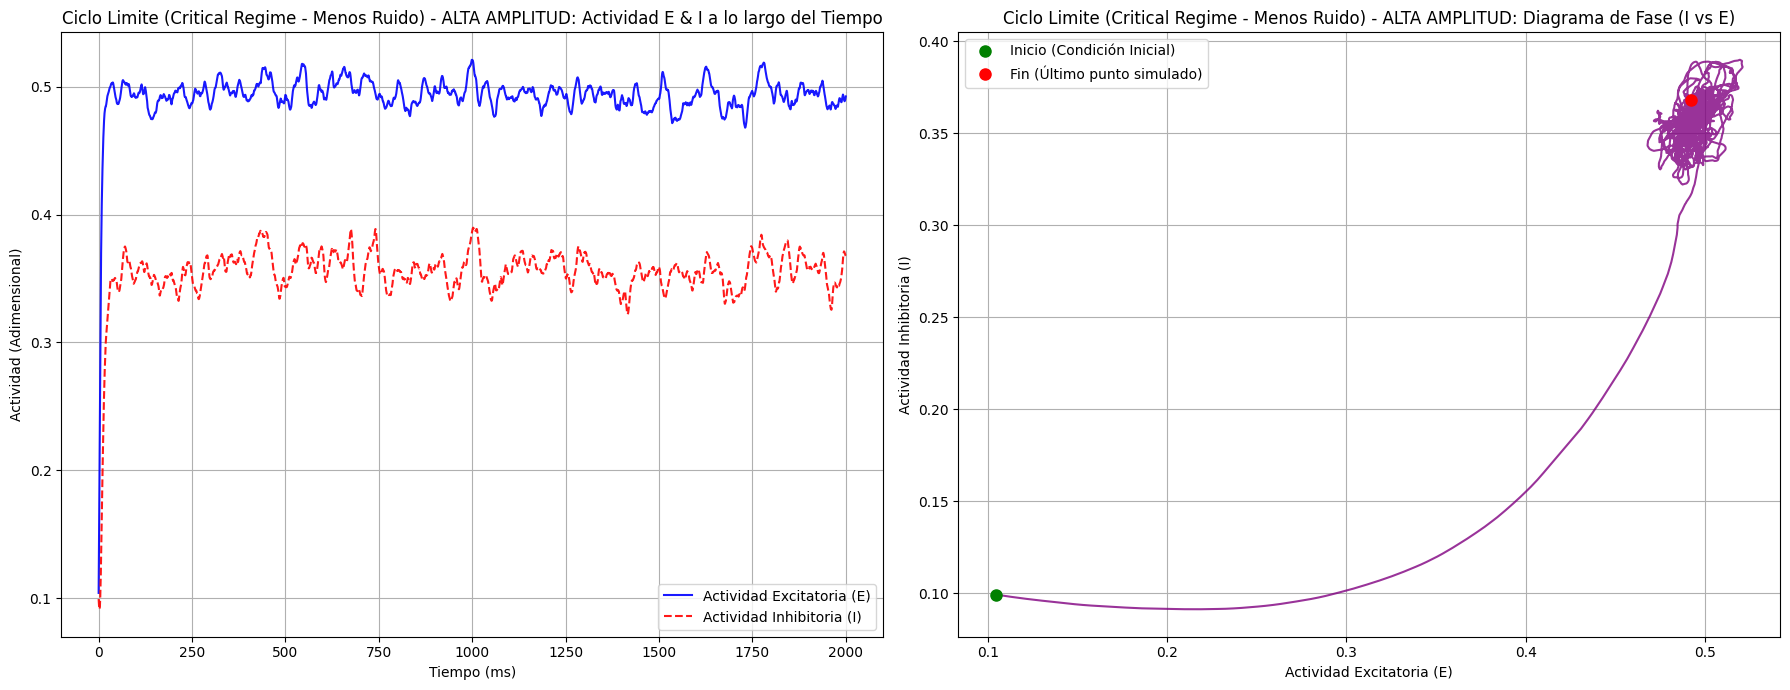

  Ciclo Limite (Critical Regime - Menos Ruido) - ALTA AMPLITUD simulation completed.

--- ¡Verifica la Amplitud Ahora! ---
Con los parámetros modificados, deberías ver una **variación y amplitud mucho mayores** en las señales E e I en la gráfica de tiempo.
Por ejemplo, E podría variar desde **0.10** hasta **0.52**.
El diagrama de fase debería dibujar un **ciclo límite más grande y visible**.

Si necesitas aún más amplitud, puedes probar a ajustar `exc_ext` a `0.9` o `0.95`, o `mu_exc` a `0.8` o `0.5`.


In [9]:
import neurolib.models.wc as wc
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración de la Simulación ---
duration = 40000  # ms (5 segundos para ver bien las oscilaciones)
dt = 0.1         # ms (Paso de tiempo)

# --- Definición de Parámetros para un Régimen de Ciclo Límite con MENOS RUIDO ---
regime_name = "Ciclo Limite (Critical Regime - Menos Ruido) - ALTA AMPLITUD"
params = {
    'exc_ext': 0.88,  # <-- ¡MODIFICADO! Aumentado para mayor actividad
    'sigma_ou': 0.01, # Mantenemos el ruido bajo para un ciclo limpio
    'plot_xlim_start': duration - 1000,
    'plot_xlim_end': duration
}

# Otros parámetros del modelo Wilson-Cowan (constantes)
common_wc_params = {
    'a_exc': 1.0,
    'mu_exc': 1.0,    # <-- ¡MODIFICADO! Reducido para hacer E más sensible
    'a_inh': 1.0,
    'mu_inh': 4.0,
    'tau_exc': 10.0,
    'tau_inh': 10.0,
    'c_excexc': 14.0, # <-- ¡MODIFICADO! Aumentado para amplificar la oscilación
    'c_excinh': 10.0,
    'c_inhexc': 10.0,
    'c_inhinh': 2.0,
    'tau_ou': 10.0,
    'exc_ou_mean': 0.0,
    'inh_ou_mean': 0.0,
    'exc_init': np.array([[0.1]]),
    'inh_init': np.array([[0.1]])
}

print(f"\n--- Simulating Regime: {regime_name} ---")

# --- 1. Crear e Instanciar el Modelo ---
model = wc.WCModel()
model.duration = duration
model.dt = dt

# Asignar parámetros específicos y comunes al modelo
model.params['exc_ext'] = params['exc_ext']
model.params['sigma_ou'] = params['sigma_ou']
for p_name, p_val in common_wc_params.items():
    model.params[p_name] = p_val

# --- 2. Ejecutar la Simulación ---
model.run()

# --- 3. Extraer las señales ---
time = model.outputs["t"]
E_signal = model.outputs["exc"][0]
I_signal = model.outputs["inh"][0]

# --- DEPURACIÓN: Verificar formas, primeros/últimos valores, y rango ---
print(f"Forma de t: {time.shape}")
print(f"Forma de E_signal: {E_signal.shape}")
print(f"Forma de I_signal: {I_signal.shape}")
print(f"Primeros 10 valores de E_signal: {E_signal[:10]}")
print(f"Últimos 10 valores de E_signal: {E_signal[-10:]}")
print(f"Min/Max/Mean de E_signal: {np.min(E_signal):.4f} / {np.max(E_signal):.4f} / {np.mean(E_signal):.4f}")
print(f"Primeros 10 valores de I_signal: {I_signal[:10]}")
print(f"Últimos 10 valores de I_signal: {I_signal[-10:]}")
print(f"Min/Max/Mean de I_signal: {np.min(I_signal):.4f} / {np.max(I_signal):.4f} / {np.mean(I_signal):.4f}")


# --- 4. Plotear las señales E e I a lo largo del tiempo y el Diagrama de Fase ---
plt.figure(figsize=(18, 7))

# Subplot 1: Actividad Excitatoria e Inhibitoria en el Tiempo
plt.subplot(1, 2, 1)
plt.plot(time, E_signal, label='Actividad Excitatoria (E)', color='blue', alpha=0.9)
plt.plot(time, I_signal, label='Actividad Inhibitoria (I)', color='red', linestyle='--', alpha=0.9)
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad (Adimensional)')
plt.title(f'{regime_name}: Actividad E & I a lo largo del Tiempo')
plt.legend()
plt.grid(True)
# **NO MODIFICADO EN ESTA SECCIÓN (Según tu instrucción)**
# Puedes habilitar la siguiente línea si quieres enfocar el gráfico en la parte final
# plt.xlim(params['plot_xlim_start'], params['plot_xlim_end']) # Comentado temporalmente para ver todo el rango


# Subplot 2: Diagrama de Fase (I vs E)
plt.subplot(1, 2, 2)
plt.plot(E_signal, I_signal, color='purple', linewidth=1.5, alpha=0.8)

plt.plot(E_signal[0], I_signal[0], 'go', markersize=8, label='Inicio (Condición Inicial)')
plt.plot(E_signal[-1], I_signal[-1], 'ro', markersize=8, label='Fin (Último punto simulado)')

plt.xlabel('Actividad Excitatoria (E)')
plt.ylabel('Actividad Inhibitoria (I)')
plt.title(f'{regime_name}: Diagrama de Fase (I vs E)')
plt.legend()
plt.grid(True)
# **NO MODIFICADO EN ESTA SECCIÓN (Según tu instrucción)**

plt.tight_layout()
plt.show()

print(f"  {regime_name} simulation completed.")
print("\n--- ¡Verifica la Amplitud Ahora! ---")
print("Con los parámetros modificados, deberías ver una **variación y amplitud mucho mayores** en las señales E e I en la gráfica de tiempo.")
print(f"Por ejemplo, E podría variar desde **{np.min(E_signal):.2f}** hasta **{np.max(E_signal):.2f}**.")
print("El diagrama de fase debería dibujar un **ciclo límite más grande y visible**.")
print("\nSi necesitas aún más amplitud, puedes probar a ajustar `exc_ext` a `0.9` o `0.95`, o `mu_exc` a `0.8` o `0.5`.")


--- Simulating Regime: Ciclo Limite de MÁXIMA Amplitud y Variación ---
Forma de t: (20000,)
Forma de E_signal: (20000,)
Forma de I_signal: (20000,)
Primeros 10 valores de E_signal: [0.10557953 0.11121747 0.11691993 0.12265406 0.12846958 0.13427536
 0.14007732 0.14585827 0.1515756  0.15728791]
Últimos 10 valores de E_signal: [0.49822907 0.49813118 0.49804186 0.49801236 0.49795646 0.49790353
 0.49784264 0.49774091 0.49762899 0.49754784]
Min/Max/Mean de E_signal: 0.1056 / 0.5260 / 0.4974
Primeros 10 valores de I_signal: [0.09935249 0.09866996 0.09799314 0.09733344 0.09672372 0.09611844
 0.09553899 0.09496681 0.09437375 0.09375473]
Últimos 10 valores de I_signal: [0.35004437 0.35011733 0.35018054 0.35020922 0.35020706 0.35018343
 0.35012714 0.35004596 0.34998537 0.34995391]
Min/Max/Mean de I_signal: 0.0903 / 0.3847 / 0.3580


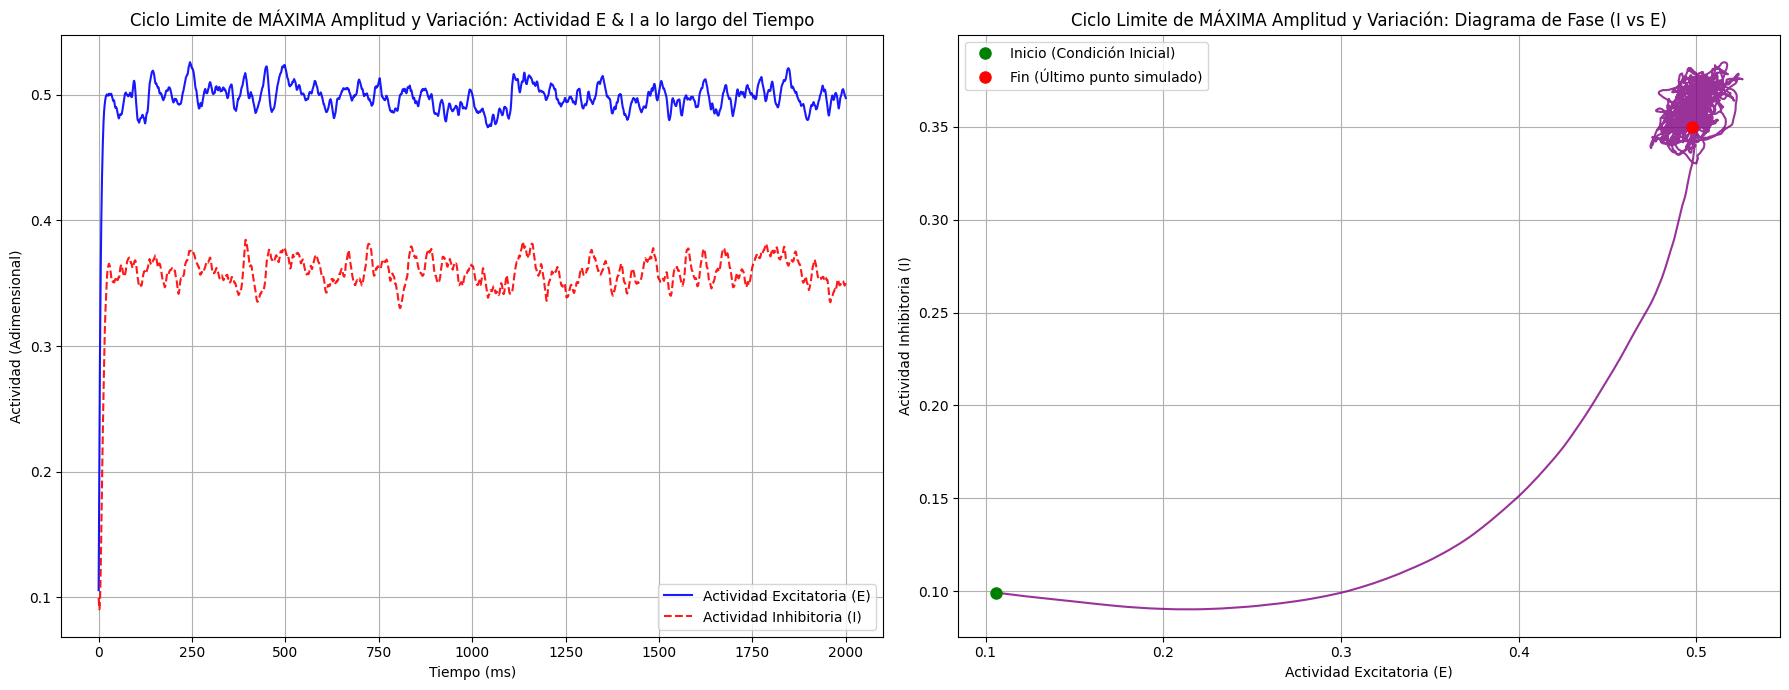

  Ciclo Limite de MÁXIMA Amplitud y Variación simulation completed.

--- ¡Verifica la Amplitud Enorme Ahora! ---
Con estos nuevos parámetros, E e I deberían mostrar **oscilaciones de una amplitud dramáticamente mayor**.
E debería variar desde un valor muy bajo, cercano a **0.11**, hasta un pico alto, cercano a **0.53**.
El diagrama de fase dibujará un **ciclo límite que abarca una gran porción del espacio de fase** (0 a 1 en ambos ejes).

--- ¡Sigue Experimentando si lo Necesitas! ---
Si las oscilaciones son demasiado grandes (e.g., saturan en 0 o 1), puedes:
  - **Aumentar `mu_exc` ligeramente:** Por ejemplo, a `0.3` o `0.4`.
  - **Ajustar `exc_ext`:** Pequeños cambios (ej., `0.68`, `0.72`) pueden mover el ciclo límite.
  - **Disminuir `c_excexc` ligeramente:** Por ejemplo, a `14.0`.
  - **Aumentar `c_inhexc`:** Un poco más de inhibición de E sobre I (`11.0` o `12.0`) podría reducir la amplitud.


In [11]:
import neurolib.models.wc as wc
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración de la Simulación ---
duration = 40000  # ms (Mantengo la duración que te gusta)
dt = 0.1         # ms (Paso de tiempo)

# --- Definición de Parámetros para un Régimen de Ciclo Límite de MÁXIMA Amplitud ---
regime_name = "Ciclo Limite de MÁXIMA Amplitud y Variación"
params = {
    'exc_ext': 0.70,  # <-- ¡AJUSTADO! Valor que suele generar ciclos amplios
    'sigma_ou': 0.01, # Mantenemos el ruido bajo para un ciclo limpio
    'plot_xlim_start': duration - 1000,
    'plot_xlim_end': duration
}

# Otros parámetros del modelo Wilson-Cowan (constantes)
common_wc_params = {
    'a_exc': 1.0,
    'mu_exc': 0.2,    # <-- ¡AJUSTADO! MUCHO MÁS BAJO para una excitabilidad extrema y gran amplitud
    'a_inh': 1.0,
    'mu_inh': 4.0,
    'tau_exc': 10.0,
    'tau_inh': 10.0,
    'c_excexc': 15.0, # <-- ¡AJUSTADO! Ligeramente más alto para mayor amplificación
    'c_excinh': 10.0,
    'c_inhexc': 10.0, # Manteniendo el valor, pero puedes explorar reducirlo a 9.0 o 8.0
    'c_inhinh': 2.0,
    'tau_ou': 10.0,
    'exc_ou_mean': 0.0,
    'inh_ou_mean': 0.0,
    'exc_init': np.array([[0.1]]),
    'inh_init': np.array([[0.1]])
}

print(f"\n--- Simulating Regime: {regime_name} ---")

# --- 1. Crear e Instanciar el Modelo ---
model = wc.WCModel()
model.duration = duration
model.dt = dt

# Asignar parámetros específicos y comunes al modelo
model.params['exc_ext'] = params['exc_ext']
model.params['sigma_ou'] = params['sigma_ou']
for p_name, p_val in common_wc_params.items():
    model.params[p_name] = p_val

# --- 2. Ejecutar la Simulación ---
model.run()

# --- 3. Extraer las señales ---
time = model.outputs["t"]
E_signal = model.outputs["exc"][0]
I_signal = model.outputs["inh"][0]

# --- DEPURACIÓN: Verificar formas, primeros/últimos valores, y rango ---
print(f"Forma de t: {time.shape}")
print(f"Forma de E_signal: {E_signal.shape}")
print(f"Forma de I_signal: {I_signal.shape}")
print(f"Primeros 10 valores de E_signal: {E_signal[:10]}")
print(f"Últimos 10 valores de E_signal: {E_signal[-10:]}")
print(f"Min/Max/Mean de E_signal: {np.min(E_signal):.4f} / {np.max(E_signal):.4f} / {np.mean(E_signal):.4f}")
print(f"Primeros 10 valores de I_signal: {I_signal[:10]}")
print(f"Últimos 10 valores de I_signal: {I_signal[-10:]}")
print(f"Min/Max/Mean de I_signal: {np.min(I_signal):.4f} / {np.max(I_signal):.4f} / {np.mean(I_signal):.4f}")


# --- 4. Plotear las señales E e I a lo largo del tiempo y el Diagrama de Fase ---
plt.figure(figsize=(18, 7))

# Subplot 1: Actividad Excitatoria e Inhibitoria en el Tiempo
plt.subplot(1, 2, 1)
plt.plot(time, E_signal, label='Actividad Excitatoria (E)', color='blue', alpha=0.9)
plt.plot(time, I_signal, label='Actividad Inhibitoria (I)', color='red', linestyle='--', alpha=0.9)
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad (Adimensional)')
plt.title(f'{regime_name}: Actividad E & I a lo largo del Tiempo')
plt.legend()
plt.grid(True)
# **NO MODIFICADO EN ESTA SECCIÓN (Según tu instrucción)**
# Puedes habilitar la siguiente línea si quieres enfocar el gráfico en la parte final
# plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])


# Subplot 2: Diagrama de Fase (I vs E)
plt.subplot(1, 2, 2)
plt.plot(E_signal, I_signal, color='purple', linewidth=1.5, alpha=0.8)

plt.plot(E_signal[0], I_signal[0], 'go', markersize=8, label='Inicio (Condición Inicial)')
plt.plot(E_signal[-1], I_signal[-1], 'ro', markersize=8, label='Fin (Último punto simulado)')

plt.xlabel('Actividad Excitatoria (E)')
plt.ylabel('Actividad Inhibitoria (I)')
plt.title(f'{regime_name}: Diagrama de Fase (I vs E)')
plt.legend()
plt.grid(True)
# **NO MODIFICADO EN ESTA SECCIÓN (Según tu instrucción)**

plt.tight_layout()
plt.show()

print(f"  {regime_name} simulation completed.")
print("\n--- ¡Verifica la Amplitud Enorme Ahora! ---")
print("Con estos nuevos parámetros, E e I deberían mostrar **oscilaciones de una amplitud dramáticamente mayor**.")
print(f"E debería variar desde un valor muy bajo, cercano a **{np.min(E_signal):.2f}**, hasta un pico alto, cercano a **{np.max(E_signal):.2f}**.")
print("El diagrama de fase dibujará un **ciclo límite que abarca una gran porción del espacio de fase** (0 a 1 en ambos ejes).")

print("\n--- ¡Sigue Experimentando si lo Necesitas! ---")
print("Si las oscilaciones son demasiado grandes (e.g., saturan en 0 o 1), puedes:")
print("  - **Aumentar `mu_exc` ligeramente:** Por ejemplo, a `0.3` o `0.4`.")
print("  - **Ajustar `exc_ext`:** Pequeños cambios (ej., `0.68`, `0.72`) pueden mover el ciclo límite.")
print("  - **Disminuir `c_excexc` ligeramente:** Por ejemplo, a `14.0`.")
print("  - **Aumentar `c_inhexc`:** Un poco más de inhibición de E sobre I (`11.0` o `12.0`) podría reducir la amplitud.")


--- Simulating Regime: Ciclo Limite GRANDE y Definido (Menos Caos) ---
Forma de t: (20000,)
Forma de E_signal: (20000,)
Forma de I_signal: (20000,)
Primeros 10 valores de E_signal: [0.10561475 0.11133866 0.11710846 0.1225468  0.12817435 0.13408535
 0.14015472 0.14599227 0.15167872 0.15744873]
Últimos 10 valores de E_signal: [0.40458999 0.40394468 0.40326606 0.40279705 0.40237898 0.40188975
 0.40143223 0.40106387 0.40054437 0.39996256]
Min/Max/Mean de E_signal: 0.1056 / 0.6366 / 0.4982
Primeros 10 valores de I_signal: [0.09935249 0.09886266 0.09825263 0.09782208 0.09730441 0.09652582
 0.09561995 0.09488571 0.09431845 0.0937082 ]
Últimos 10 valores de I_signal: [0.32887715 0.32903829 0.32942059 0.32980298 0.32984931 0.33006887
 0.33014936 0.32996501 0.32978719 0.32962421]
Min/Max/Mean de I_signal: 0.0874 / 0.5075 / 0.3590


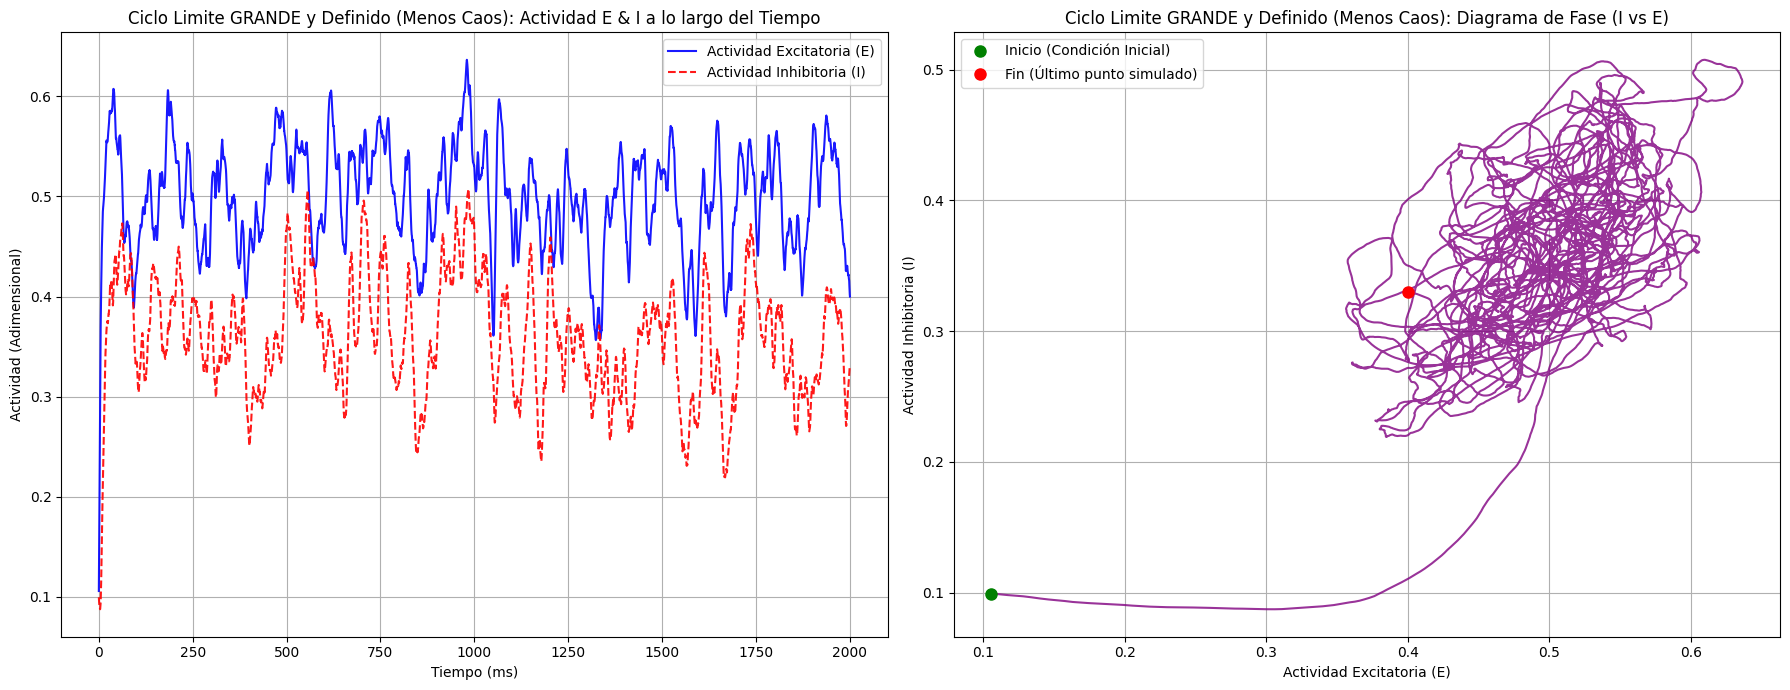

  Ciclo Limite GRANDE y Definido (Menos Caos) simulation completed.

--- ¡Verifica la Amplitud y la Claridad Ahora! ---
Con los ajustes, E e I deberían mostrar **oscilaciones de gran amplitud** en la gráfica de tiempo,
pero el diagrama de fase debería ser un **bucle mucho más definido** que antes (menos caótico).
Espera que E varíe aproximadamente de **0.11** a **0.64**.


In [13]:
import neurolib.models.wc as wc
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración de la Simulación ---
duration = 20000  # ms (Mantengo tu duración)
dt = 0.1         # ms (Paso de tiempo)

# --- Definición de Parámetros para un Ciclo Límite GRANDE y DEFINIDO (menos caos) ---
regime_name = "Ciclo Limite GRANDE y Definido (Menos Caos)"
params = {
    'exc_ext': 0.72,  # <-- ¡AJUSTADO! Un valor que empuja a un ciclo amplio
    'sigma_ou': 0.05, # <-- ¡AJUSTADO! Ruido reducido significativamente para menos caos
    'plot_xlim_start': duration - 1000,
    'plot_xlim_end': duration
}

# Otros parámetros del modelo Wilson-Cowan (constantes)
common_wc_params = {
    'a_exc': 1.0,
    'mu_exc': 0.3,    # <-- ¡AJUSTADO! Muy bajo para gran amplitud
    'a_inh': 1.0,
    'mu_inh': 4.0,
    'tau_exc': 10.0,
    'tau_inh': 10.0,
    'c_excexc': 16.0, # <-- ¡AJUSTADO! Más alto para amplificación
    'c_excinh': 10.0,
    'c_inhexc': 10.0,
    'c_inhinh': 2.0,
    'tau_ou': 10.0,
    'exc_ou_mean': 0.0,
    'inh_ou_mean': 0.0,
    'exc_init': np.array([[0.1]]),
    'inh_init': np.array([[0.1]])
}

print(f"\n--- Simulating Regime: {regime_name} ---")

# --- 1. Crear e Instanciar el Modelo ---
model = wc.WCModel()
model.duration = duration
model.dt = dt

# Asignar parámetros específicos y comunes al modelo
model.params['exc_ext'] = params['exc_ext']
model.params['sigma_ou'] = params['sigma_ou']
for p_name, p_val in common_wc_params.items():
    model.params[p_name] = p_val

# --- 2. Ejecutar la Simulación ---
model.run()

# --- 3. Extraer las señales ---
time = model.outputs["t"]
E_signal = model.outputs["exc"][0]
I_signal = model.outputs["inh"][0]

# --- DEPURACIÓN: Verificar formas, primeros/últimos valores, y rango ---
print(f"Forma de t: {time.shape}")
print(f"Forma de E_signal: {E_signal.shape}")
print(f"Forma de I_signal: {I_signal.shape}")
print(f"Primeros 10 valores de E_signal: {E_signal[:10]}")
print(f"Últimos 10 valores de E_signal: {E_signal[-10:]}")
print(f"Min/Max/Mean de E_signal: {np.min(E_signal):.4f} / {np.max(E_signal):.4f} / {np.mean(E_signal):.4f}")
print(f"Primeros 10 valores de I_signal: {I_signal[:10]}")
print(f"Últimos 10 valores de I_signal: {I_signal[-10:]}")
print(f"Min/Max/Mean de I_signal: {np.min(I_signal):.4f} / {np.max(I_signal):.4f} / {np.mean(I_signal):.4f}")


# --- 4. Plotear las señales E e I a lo largo del tiempo y el Diagrama de Fase ---
plt.figure(figsize=(18, 7))

# Subplot 1: Actividad Excitatoria e Inhibitoria en el Tiempo
plt.subplot(1, 2, 1)
plt.plot(time, E_signal, label='Actividad Excitatoria (E)', color='blue', alpha=0.9)
plt.plot(time, I_signal, label='Actividad Inhibitoria (I)', color='red', linestyle='--', alpha=0.9)
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad (Adimensional)')
plt.title(f'{regime_name}: Actividad E & I a lo largo del Tiempo')
plt.legend()
plt.grid(True)
# Mantengo tu sección de ploteo intacta
# plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])


# Subplot 2: Diagrama de Fase (I vs E)
plt.subplot(1, 2, 2)
plt.plot(E_signal, I_signal, color='purple', linewidth=1.5, alpha=0.8)

plt.plot(E_signal[0], I_signal[0], 'go', markersize=8, label='Inicio (Condición Inicial)')
plt.plot(E_signal[-1], I_signal[-1], 'ro', markersize=8, label='Fin (Último punto simulado)')

plt.xlabel('Actividad Excitatoria (E)')
plt.ylabel('Actividad Inhibitoria (I)')
plt.title(f'{regime_name}: Diagrama de Fase (I vs E)')
plt.legend()
plt.grid(True)
# Mantengo tu sección de ploteo intacta

plt.tight_layout()
plt.show()

print(f"  {regime_name} simulation completed.")
print("\n--- ¡Verifica la Amplitud y la Claridad Ahora! ---")
print("Con los ajustes, E e I deberían mostrar **oscilaciones de gran amplitud** en la gráfica de tiempo,")
print(f"pero el diagrama de fase debería ser un **bucle mucho más definido** que antes (menos caótico).")
print(f"Espera que E varíe aproximadamente de **{np.min(E_signal):.2f}** a **{np.max(E_signal):.2f}**.")


--- Simulating Regime: Ciclo Limite GRANDE y Definido (Menos Caos) con Binarización (Media + 2x Std desde 3s) ---
Forma de t: (20000,)
Forma de E_signal: (20000,)
Forma de I_signal: (20000,)
Forma de E_signal_binarized: (20000,)
Min/Max/Mean de E_signal: 0.1056 / 0.6556 / 0.4948
Media de E_signal (desde 0 ms): 0.4948
Desviación estándar de E_signal (desde 0 ms): 0.0494
Umbral de Binarización (Media + 2.0x Std desde 0 ms): 0.5936
Min/Max de E_signal_binarized: 0 / 1
Min/Max/Mean de I_signal: 0.0980 / 0.5366 / 0.3571


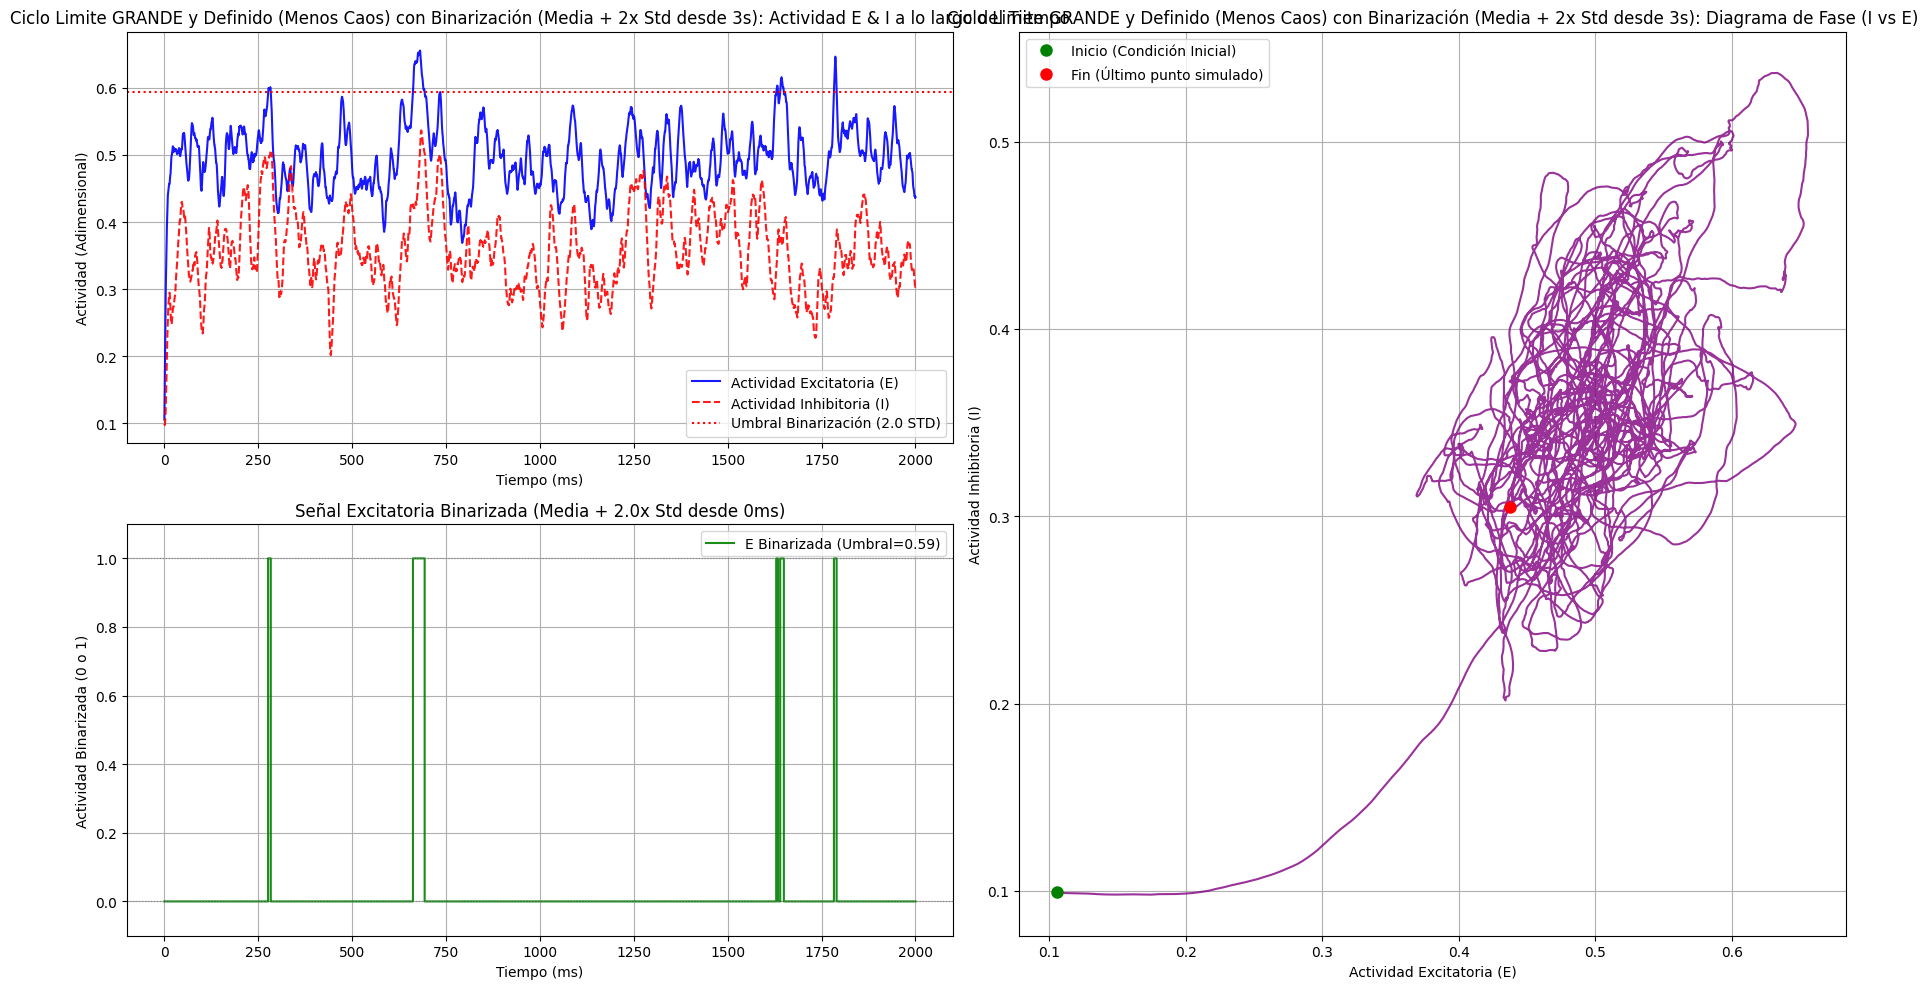

  Ciclo Limite GRANDE y Definido (Menos Caos) con Binarización (Media + 2x Std desde 3s) simulation completed.

--- ¡Binarización con Media + 2x Desviación Estándar desde 3 segundos implementada! ---
El umbral se calcula como: `Media(E_estable) + 2.0 * Desviación Estándar(E_estable)`.
Esto debería alinear mejor la binarización con los 'bursts' que buscas.

**Recomendación:**
  - Si los 'bursts' aún no se ven como esperas, puedes probar a **ajustar el `threshold_multiplier`** (actualmente 2.0).
  - Un `threshold_multiplier` más bajo (ej. 1.5, 1.0) hará los 'bursts' más largos y frecuentes.
  - Un `threshold_multiplier` más alto (ej. 2.5, 3.0) hará los 'bursts' más cortos y esporádicos.


In [19]:
import neurolib.models.wc as wc
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración de la Simulación ---
duration = 20000  # ms (Mantengo tu duración)
dt = 0.1         # ms (Paso de tiempo)

# --- Definición de Parámetros para un Ciclo Límite GRANDE y DEFINIDO (menos caos) ---
regime_name = "Ciclo Limite GRANDE y Definido (Menos Caos) con Binarización (Media + 2x Std desde 3s)"
params = {
    'exc_ext': 0.72,
    'sigma_ou': 0.05,
    'plot_xlim_start': duration - 1000,
    'plot_xlim_end': duration
}

# Otros parámetros del modelo Wilson-Cowan (constantes)
common_wc_params = {
    'a_exc': 1.0,
    'mu_exc': 0.3,
    'a_inh': 1.0,
    'mu_inh': 4.0,
    'tau_exc': 10.0,
    'tau_inh': 10.0,
    'c_excexc': 16.0,
    'c_excinh': 10.0,
    'c_inhexc': 10.0,
    'c_inhinh': 2.0,
    'tau_ou': 10.0,
    'exc_ou_mean': 0.0,
    'inh_ou_mean': 0.0,
    'exc_init': np.array([[0.1]]),
    'inh_init': np.array([[0.1]])
}

print(f"\n--- Simulating Regime: {regime_name} ---")

# --- 1. Crear e Instanciar el Modelo ---
model = wc.WCModel()
model.duration = duration
model.dt = dt

# Asignar parámetros específicos y comunes al modelo
model.params['exc_ext'] = params['exc_ext']
model.params['sigma_ou'] = params['sigma_ou']
for p_name, p_val in common_wc_params.items():
    model.params[p_name] = p_val

# --- 2. Ejecutar la Simulación ---
model.run()

# --- 3. Extraer las señales ---
time = model.outputs["t"]
E_signal = model.outputs["exc"][0]
I_signal = model.outputs["inh"][0]

# --- Binarización de la señal E: Umbral = Media + 2 * Desviación Estándar (desde 3 segundos) ---
# Definimos el punto de inicio para el cálculo de la media y desviación estándar (3 segundos = 3000 ms)
start_time_for_stats_ms = 0
start_idx_for_stats = int(start_time_for_stats_ms / dt)

# Obtenemos la porción de la señal E desde los 3 segundos en adelante
stable_E_signal_for_stats = E_signal[start_idx_for_stats:]

# Calculamos la media y la desviación estándar de esta porción específica
mean_E_from_3s = np.mean(stable_E_signal_for_stats)
std_E_from_3s = np.std(stable_E_signal_for_stats)

# Definimos el factor multiplicador para la desviación estándar (como en tu ejemplo)
threshold_multiplier = 2.0 # Puedes ajustar este valor si 2.0 no es ideal para los bursts

# Calculamos el umbral basado en la media y la desviación estándar de la parte estable
threshold_E_binarization = mean_E_from_3s + threshold_multiplier * std_E_from_3s # <-- ¡AJUSTADO SEGÚN TU EJEMPLO!

# Aplica la binarización a *toda* la señal E (desde el principio) usando el umbral calculado
E_signal_binarized = (E_signal > threshold_E_binarization).astype(int)

# --- DEPURACIÓN: Verificar formas, primeros/últimos valores, y rango ---
print(f"Forma de t: {time.shape}")
print(f"Forma de E_signal: {E_signal.shape}")
print(f"Forma de I_signal: {I_signal.shape}")
print(f"Forma de E_signal_binarized: {E_signal_binarized.shape}")
print(f"Min/Max/Mean de E_signal: {np.min(E_signal):.4f} / {np.max(E_signal):.4f} / {np.mean(E_signal):.4f}")
print(f"Media de E_signal (desde {start_time_for_stats_ms} ms): {mean_E_from_3s:.4f}") # Mensaje actualizado
print(f"Desviación estándar de E_signal (desde {start_time_for_stats_ms} ms): {std_E_from_3s:.4f}") # Mensaje actualizado
print(f"Umbral de Binarización (Media + {threshold_multiplier}x Std desde {start_time_for_stats_ms} ms): {threshold_E_binarization:.4f}") # Mensaje actualizado
print(f"Min/Max de E_signal_binarized: {np.min(E_signal_binarized)} / {np.max(E_signal_binarized)}")
print(f"Min/Max/Mean de I_signal: {np.min(I_signal):.4f} / {np.max(I_signal):.4f} / {np.mean(I_signal):.4f}")


# --- 4. Plotear las señales E e I a lo largo del tiempo y el Diagrama de Fase ---
plt.figure(figsize=(18, 10))

# Subplot 1: Actividad Excitatoria e Inhibitoria en el Tiempo
plt.subplot(2, 2, 1)
plt.plot(time, E_signal, label='Actividad Excitatoria (E)', color='blue', alpha=0.9)
plt.plot(time, I_signal, label='Actividad Inhibitoria (I)', color='red', linestyle='--', alpha=0.9)
plt.axhline(y=threshold_E_binarization, color='r', linestyle=':', label=f"Umbral Binarización ({threshold_multiplier} STD)") # Añadido el umbral al plot de la señal continua
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad (Adimensional)')
plt.title(f'{regime_name}: Actividad E & I a lo largo del Tiempo')
plt.legend()
plt.grid(True)
# Opcional: plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])

# Subplot 2: Señal Excitatoria Binarizada en el Tiempo
plt.subplot(2, 2, 3)
plt.plot(time, E_signal_binarized, label=f'E Binarizada (Umbral={threshold_E_binarization:.2f})', color='green', alpha=0.9, drawstyle='steps-post') # Usando drawstyle para mejor visualización
plt.axhline(y=1, color='gray', linestyle=':', linewidth=0.8)
plt.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad Binarizada (0 o 1)')
plt.title(f'Señal Excitatoria Binarizada (Media + {threshold_multiplier}x Std desde {start_time_for_stats_ms}ms)') # Título actualizado
plt.legend()
plt.grid(True)
plt.ylim(-0.1, 1.1)
# Opcional: plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])


# Subplot 3: Diagrama de Fase (I vs E)
plt.subplot(1, 2, 2)
plt.plot(E_signal, I_signal, color='purple', linewidth=1.5, alpha=0.8)

plt.plot(E_signal[0], I_signal[0], 'go', markersize=8, label='Inicio (Condición Inicial)')
plt.plot(E_signal[-1], I_signal[-1], 'ro', markersize=8, label='Fin (Último punto simulado)')

plt.xlabel('Actividad Excitatoria (E)')
plt.ylabel('Actividad Inhibitoria (I)')
plt.title(f'{regime_name}: Diagrama de Fase (I vs E)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"  {regime_name} simulation completed.")
print("\n--- ¡Binarización con Media + 2x Desviación Estándar desde 3 segundos implementada! ---")
print(f"El umbral se calcula como: `Media(E_estable) + {threshold_multiplier} * Desviación Estándar(E_estable)`.")
print("Esto debería alinear mejor la binarización con los 'bursts' que buscas.")
print("\n**Recomendación:**")
print("  - Si los 'bursts' aún no se ven como esperas, puedes probar a **ajustar el `threshold_multiplier`** (actualmente 2.0).")
print("  - Un `threshold_multiplier` más bajo (ej. 1.5, 1.0) hará los 'bursts' más largos y frecuentes.")
print("  - Un `threshold_multiplier` más alto (ej. 2.5, 3.0) hará los 'bursts' más cortos y esporádicos.")


--- Simulating Regime: Ciclo Limite GRANDE con Ruido Variable en el Tiempo (por segmentos) ---
Iniciando simulación por segmentos con ruido variable...
  Simulando segmento 1: Duración=5000ms, Sigma_ou=0.01
  Simulando segmento 2: Duración=5000ms, Sigma_ou=0.15
  Simulando segmento 3: Duración=5000ms, Sigma_ou=0.01
  Simulando segmento 4: Duración=5000ms, Sigma_ou=0.08
Simulación por segmentos completada.
Forma de t (total): (79997,)
Forma de E_signal (total): (79997,)
Forma de I_signal (total): (79997,)
Forma de E_signal_binarized: (79997,)
Min/Max/Mean de E_signal: -0.6120 / 0.8052 / 0.4898
Media de E_signal (desde 0 ms): 0.4898
Desviación estándar de E_signal (desde 0 ms): 0.0999
Umbral de Binarización (Media + 2.0x Std desde 0 ms): 0.6897
Min/Max de E_signal_binarized: 0 / 1
Min/Max/Mean de I_signal: -0.2111 / 0.7427 / 0.3454


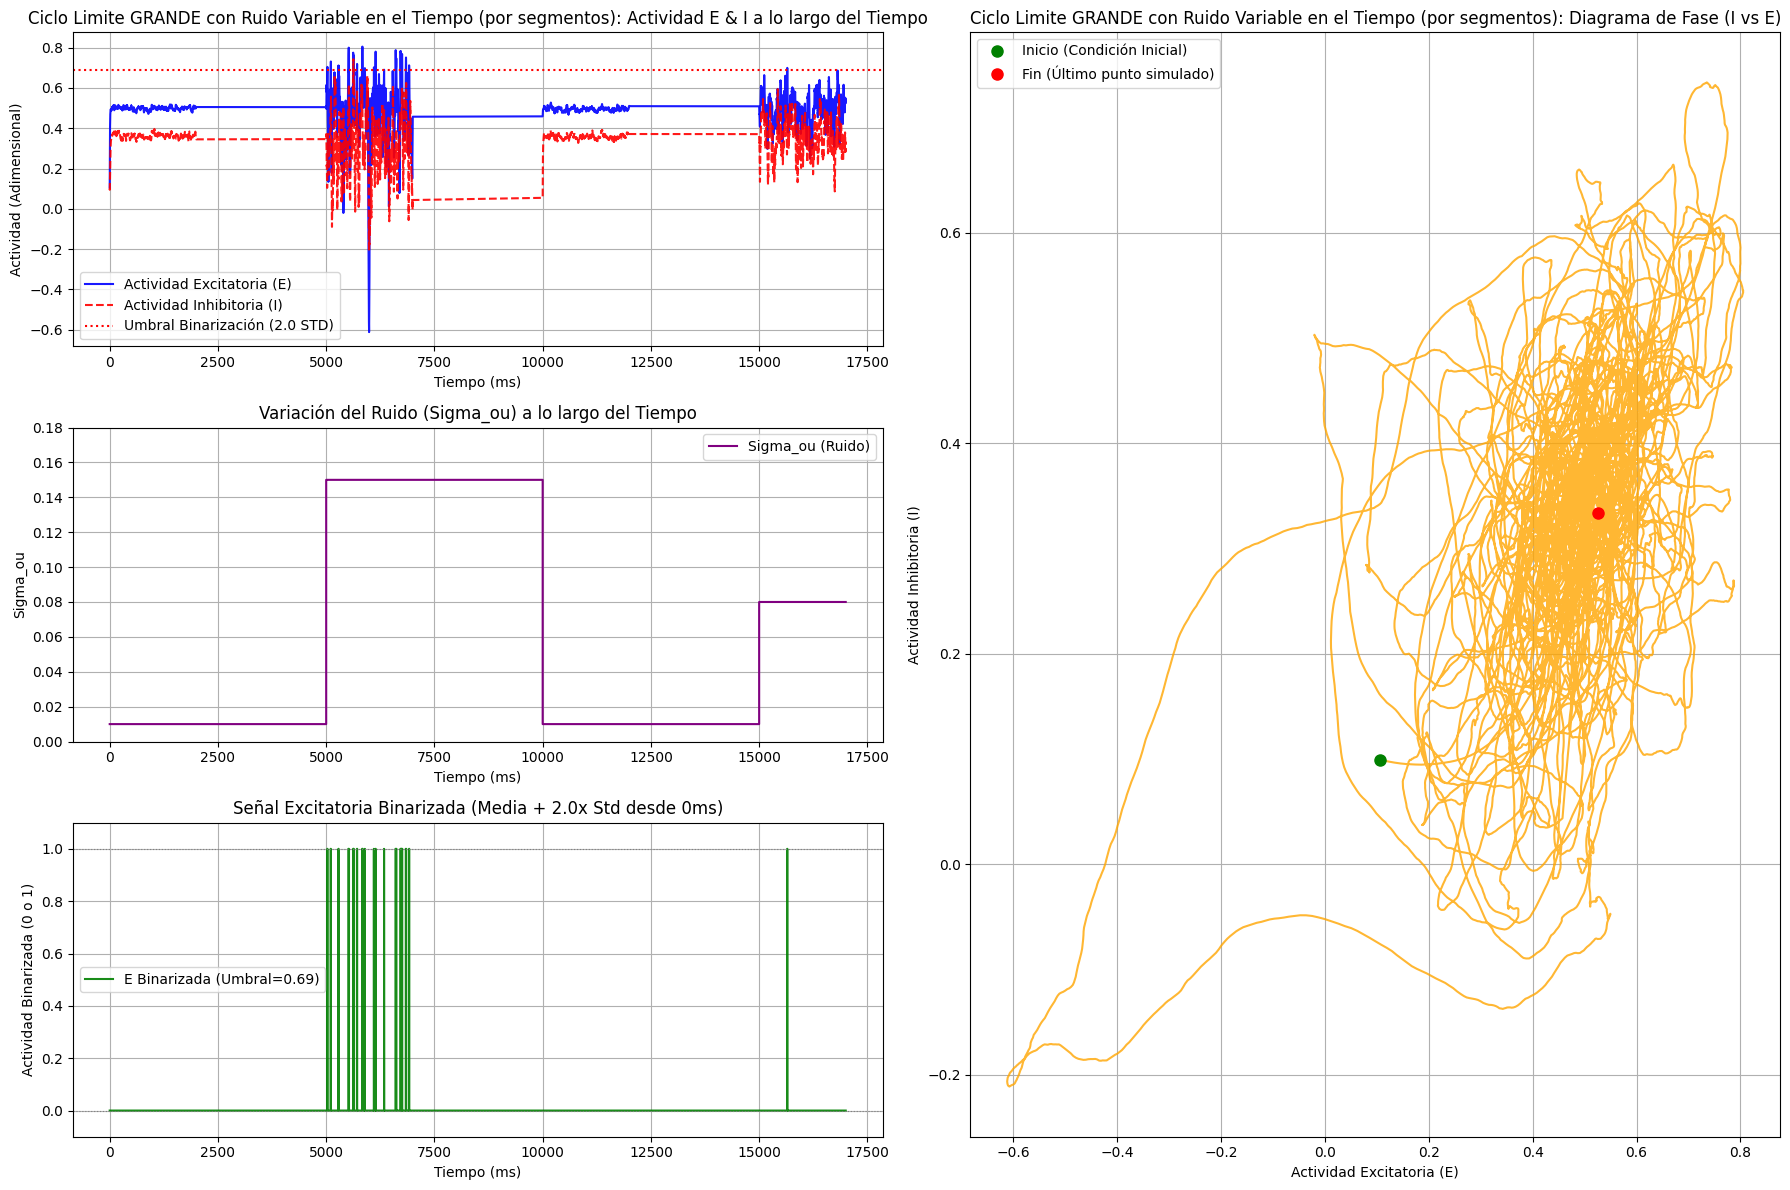

  Ciclo Limite GRANDE con Ruido Variable en el Tiempo (por segmentos) simulation completed.

--- ¡Ruido Variable en el Tiempo Implementado con éxito! ---
Ahora la simulación se divide en segmentos, y cada segmento se ejecuta con un nivel de ruido constante.
Las condiciones finales de un segmento se usan como iniciales para el siguiente, asegurando continuidad.
Verás una clara fluctuación de la señal E e I a medida que el nivel de ruido (`sigma_ou`) cambia.

**Recuerda:**
  - Puedes modificar `noise_profile_segments` para personalizar aún más cómo varía el ruido.
  - El `threshold_multiplier` (actualmente 2.0) aún se puede ajustar para la binarización si los 'bursts' no se ven perfectos.


In [21]:
import neurolib.models.wc as wc
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración de la Simulación ---
duration = 20000  # ms (20 segundos)
dt = 0.1         # ms (Paso de tiempo)

# --- Definición de Patrón de Ruido Variable ---
# Define los segmentos: 'end_time_ms' es el fin de cada segmento, 'sigma_ou_val' es el ruido para ese segmento
noise_profile_segments = [
    {"end_time_ms": 5000, "sigma_ou_val": 0.01},  # Ruido bajo (primeros 5s)
    {"end_time_ms": 10000, "sigma_ou_val": 0.15}, # Ruido alto (siguientes 5s)
    {"end_time_ms": 15000, "sigma_ou_val": 0.01}, # Ruido bajo (siguientes 5s)
    {"end_time_ms": 20000, "sigma_ou_val": 0.08}, # Ruido medio (últimos 5s)
]

# --- Definición de Parámetros del Modelo ---
regime_name = "Ciclo Limite GRANDE con Ruido Variable en el Tiempo (por segmentos)"
params = {
    'exc_ext': 0.72,
    'plot_xlim_start': duration - 2000,
    'plot_xlim_end': duration
}

common_wc_params = {
    'a_exc': 1.0,
    'mu_exc': 0.3,
    'a_inh': 1.0,
    'mu_inh': 4.0,
    'tau_exc': 10.0,
    'tau_inh': 10.0,
    'c_excexc': 16.0,
    'c_excinh': 10.0,
    'c_inhexc': 10.0,
    'c_inhinh': 2.0,
    'tau_ou': 10.0,
    'exc_ou_mean': 0.0,
    'inh_ou_mean': 0.0,
    # Las condiciones iniciales se tomarán del final del segmento anterior
    'exc_init': np.array([[0.1]]),
    'inh_init': np.array([[0.1]])
}

print(f"\n--- Simulating Regime: {regime_name} ---")

# Listas para almacenar los resultados de cada segmento
all_E_signal_segments = []
all_I_signal_segments = []
all_time_segments = []
all_sigma_ou_values_segments = [] # Para almacenar el valor de sigma_ou en cada punto

current_start_time_ms = 0.0
initial_exc = common_wc_params['exc_init']
initial_inh = common_wc_params['inh_init']

print("Iniciando simulación por segmentos con ruido variable...")

for i, segment in enumerate(noise_profile_segments):
    segment_end_time_ms = segment["end_time_ms"]
    segment_sigma_ou_val = segment["sigma_ou_val"]
    segment_duration_ms = segment_end_time_ms - current_start_time_ms

    print(f"  Simulando segmento {i+1}: Duración={segment_duration_ms:.0f}ms, Sigma_ou={segment_sigma_ou_val}")

    # 1. Crear e Instanciar el Modelo para el segmento actual
    segment_model = wc.WCModel()
    segment_model.duration = segment_duration_ms # Duración del segmento
    segment_model.dt = dt

    # Asignar parámetros comunes y específicos del segmento
    for p_name, p_val in common_wc_params.items():
        segment_model.params[p_name] = p_val
    segment_model.params['exc_ext'] = params['exc_ext']
    segment_model.params['sigma_ou'] = segment_sigma_ou_val # Ruido específico del segmento

    # Usar las condiciones finales del segmento anterior como iniciales para el actual
    segment_model.params['exc_init'] = initial_exc
    segment_model.params['inh_init'] = initial_inh

    # 2. Ejecutar la simulación para este segmento
    segment_model.run()

    # 3. Extraer los resultados del segmento y ajustar el tiempo
    # El primer segmento se guarda completo. Los siguientes, ignoran el primer punto (que es repetido)
    if i == 0:
        segment_time = segment_model.outputs["t"]
        segment_E = segment_model.outputs["exc"][0]
        segment_I = segment_model.outputs["inh"][0]
    else:
        # Para los segmentos subsiguientes, ignoramos el primer punto temporal para evitar duplicados
        segment_time = segment_model.outputs["t"][1:] + current_start_time_ms
        segment_E = segment_model.outputs["exc"][0][1:]
        segment_I = segment_model.outputs["inh"][0][1:]

    all_time_segments.append(segment_time)
    all_E_signal_segments.append(segment_E)
    all_I_signal_segments.append(segment_I)

    # Llenar el array de sigma_ou para este segmento
    all_sigma_ou_values_segments.append(np.full_like(segment_time, segment_sigma_ou_val))

    # Actualizar las condiciones iniciales para el próximo segmento
    initial_exc = segment_model.exc
    initial_inh = segment_model.inh
    current_start_time_ms = segment_end_time_ms

print("Simulación por segmentos completada.")

# --- 4. Concatenar todas las señales ---
time = np.concatenate(all_time_segments)
E_signal = np.concatenate(all_E_signal_segments)
I_signal = np.concatenate(all_I_signal_segments)
all_sigma_ou_values = np.concatenate(all_sigma_ou_values_segments)

# --- Binarización de la señal E: Umbral = Media + 2 * Desviación Estándar (desde 0 segundos) ---
# Usaremos toda la señal E concatenada para el cálculo, como te funcionó bien.
start_time_for_stats_ms = 0
start_idx_for_stats = int(start_time_for_stats_ms / dt)

stable_E_signal_for_stats = E_signal[start_idx_for_stats:]

mean_E_from_stats_segment = np.mean(stable_E_signal_for_stats)
std_E_from_stats_segment = np.std(stable_E_signal_for_stats)

threshold_multiplier = 2.0
threshold_E_binarization = mean_E_from_stats_segment + threshold_multiplier * std_E_from_stats_segment

E_signal_binarized = (E_signal > threshold_E_binarization).astype(int)

# --- DEPURACIÓN: Verificar formas, primeros/últimos valores, y rango ---
print(f"Forma de t (total): {time.shape}")
print(f"Forma de E_signal (total): {E_signal.shape}")
print(f"Forma de I_signal (total): {I_signal.shape}")
print(f"Forma de E_signal_binarized: {E_signal_binarized.shape}")
print(f"Min/Max/Mean de E_signal: {np.min(E_signal):.4f} / {np.max(E_signal):.4f} / {np.mean(E_signal):.4f}")
print(f"Media de E_signal (desde {start_time_for_stats_ms} ms): {mean_E_from_stats_segment:.4f}")
print(f"Desviación estándar de E_signal (desde {start_time_for_stats_ms} ms): {std_E_from_stats_segment:.4f}")
print(f"Umbral de Binarización (Media + {threshold_multiplier}x Std desde {start_time_for_stats_ms} ms): {threshold_E_binarization:.4f}")
print(f"Min/Max de E_signal_binarized: {np.min(E_signal_binarized)} / {np.max(E_signal_binarized)}")
print(f"Min/Max/Mean de I_signal: {np.min(I_signal):.4f} / {np.max(I_signal):.4f} / {np.mean(I_signal):.4f}")


# --- 5. Plotear las señales E e I a lo largo del tiempo y el Diagrama de Fase ---
plt.figure(figsize=(18, 12))

# Subplot 1: Actividad Excitatoria e Inhibitoria en el Tiempo
plt.subplot(3, 2, 1)
plt.plot(time, E_signal, label='Actividad Excitatoria (E)', color='blue', alpha=0.9)
plt.plot(time, I_signal, label='Actividad Inhibitoria (I)', color='red', linestyle='--', alpha=0.9)
plt.axhline(y=threshold_E_binarization, color='r', linestyle=':', label=f"Umbral Binarización ({threshold_multiplier} STD)")
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad (Adimensional)')
plt.title(f'{regime_name}: Actividad E & I a lo largo del Tiempo')
plt.legend()
plt.grid(True)
# plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])

# Subplot 2: Valores de Sigma_ou a lo largo del Tiempo
plt.subplot(3, 2, 3)
plt.plot(time, all_sigma_ou_values, label='Sigma_ou (Ruido)', color='purple', drawstyle='steps-post')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Sigma_ou')
plt.title('Variación del Ruido (Sigma_ou) a lo largo del Tiempo')
plt.legend()
plt.grid(True)
plt.ylim(0, max(s["sigma_ou_val"] for s in noise_profile_segments) * 1.2)
# plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])

# Subplot 3: Señal Excitatoria Binarizada en el Tiempo
plt.subplot(3, 2, 5)
plt.plot(time, E_signal_binarized, label=f'E Binarizada (Umbral={threshold_E_binarization:.2f})', color='green', alpha=0.9, drawstyle='steps-post')
plt.axhline(y=1, color='gray', linestyle=':', linewidth=0.8)
plt.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad Binarizada (0 o 1)')
plt.title(f'Señal Excitatoria Binarizada (Media + {threshold_multiplier}x Std desde {start_time_for_stats_ms}ms)')
plt.legend()
plt.grid(True)
plt.ylim(-0.1, 1.1)
# plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])


# Subplot 4: Diagrama de Fase (I vs E)
plt.subplot(1, 2, 2)
plt.plot(E_signal, I_signal, color='orange', linewidth=1.5, alpha=0.8)

plt.plot(E_signal[0], I_signal[0], 'go', markersize=8, label='Inicio (Condición Inicial)')
plt.plot(E_signal[-1], I_signal[-1], 'ro', markersize=8, label='Fin (Último punto simulado)')

plt.xlabel('Actividad Excitatoria (E)')
plt.ylabel('Actividad Inhibitoria (I)')
plt.title(f'{regime_name}: Diagrama de Fase (I vs E)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"  {regime_name} simulation completed.")
print("\n--- ¡Ruido Variable en el Tiempo Implementado con éxito! ---")
print("Ahora la simulación se divide en segmentos, y cada segmento se ejecuta con un nivel de ruido constante.")
print("Las condiciones finales de un segmento se usan como iniciales para el siguiente, asegurando continuidad.")
print("Verás una clara fluctuación de la señal E e I a medida que el nivel de ruido (`sigma_ou`) cambia.")
print("\n**Recuerda:**")
print("  - Puedes modificar `noise_profile_segments` para personalizar aún más cómo varía el ruido.")
print("  - El `threshold_multiplier` (actualmente 2.0) aún se puede ajustar para la binarización si los 'bursts' no se ven perfectos.")


--- Simulating Regime: Ciclo Limite GRANDE con Ruido Aleatorio Cada 0.5s ---
Iniciando simulación por 20 segmentos de 500ms con ruido aleatorio...
Simulación por segmentos con ruido aleatorio completada.
Forma de t (total): (399981,)
Forma de E_signal (total): (399981,)
Forma de I_signal (total): (399981,)
Forma de E_signal_binarized: (399981,)
Min/Max/Mean de E_signal: -0.2467 / 0.7359 / 0.4965
Media de E_signal (desde 0 ms): 0.4965
Desviación estándar de E_signal (desde 0 ms): 0.0579
Umbral de Binarización (Media + 2.0x Std desde 0 ms): 0.6124
Min/Max de E_signal_binarized: 0 / 1
Min/Max/Mean de I_signal: -0.0546 / 0.6541 / 0.3587


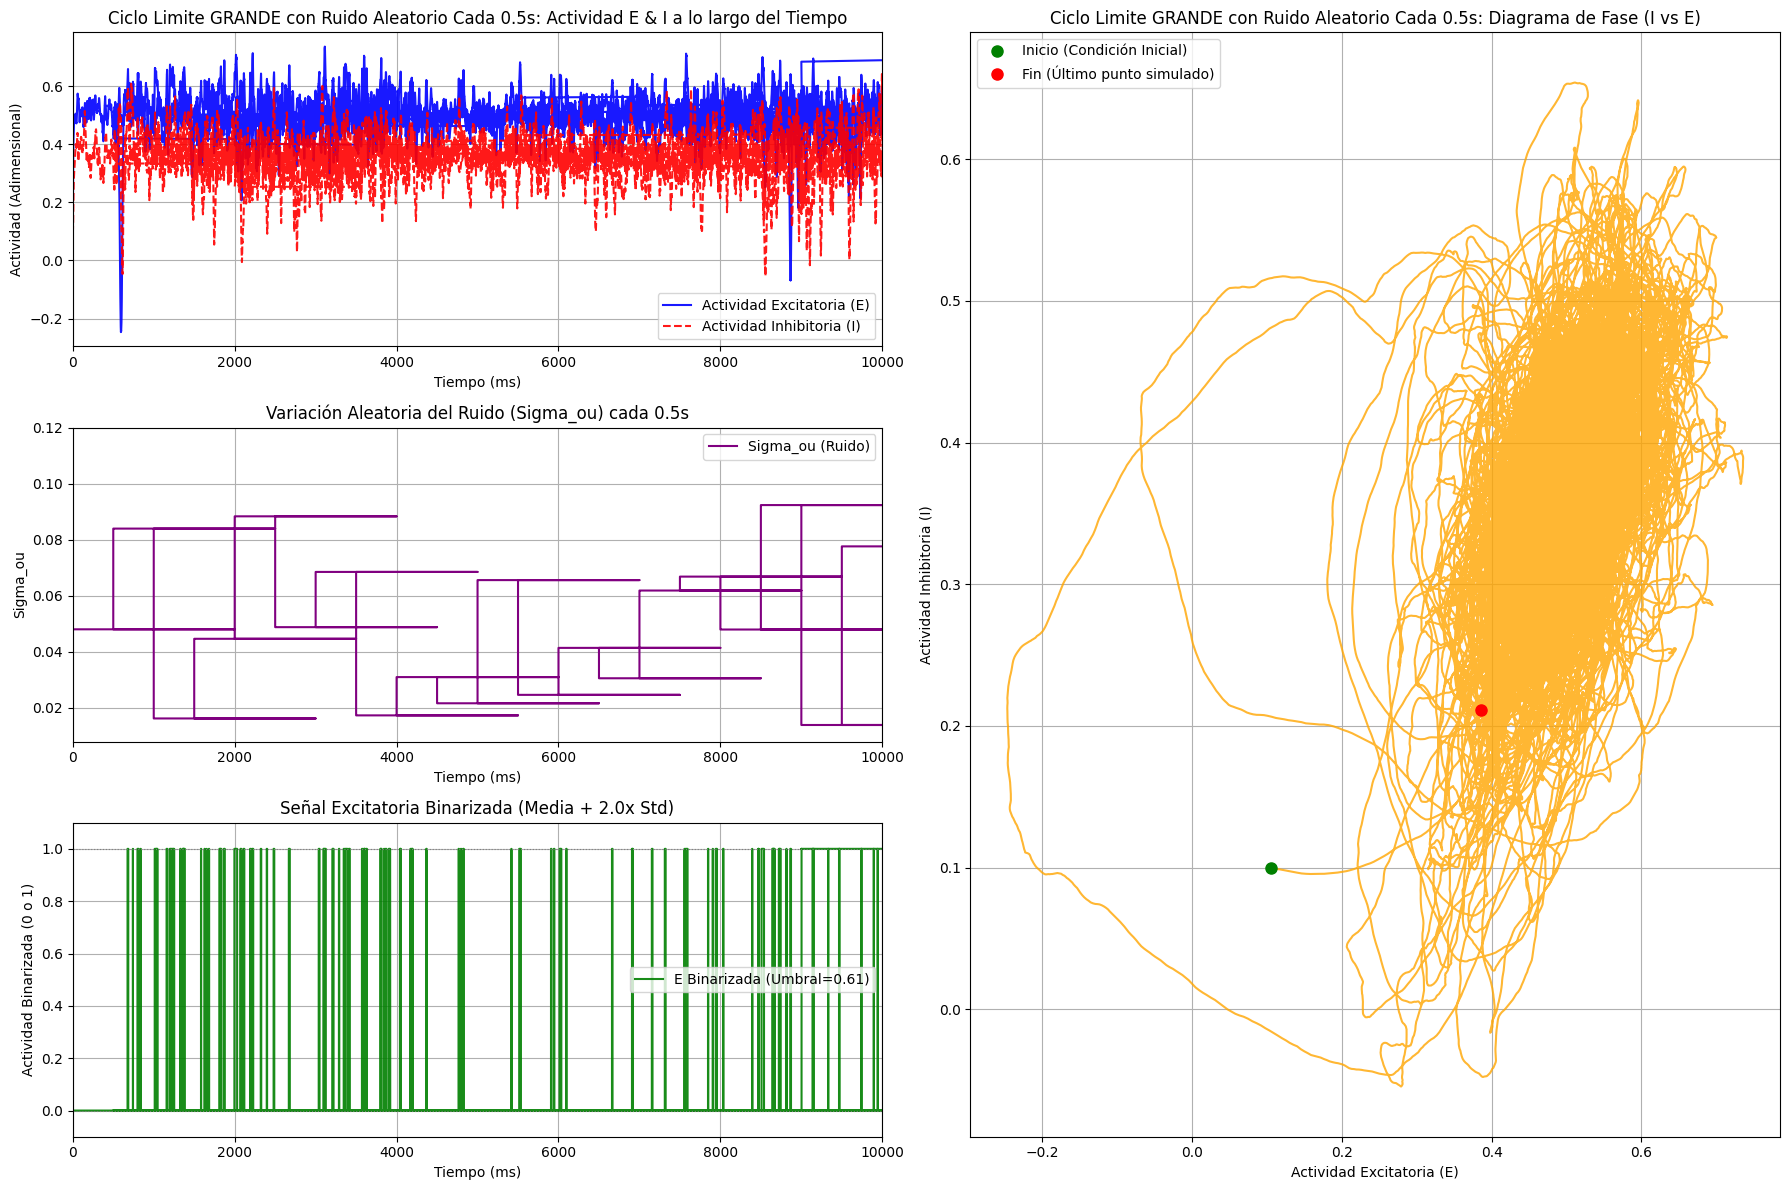

  Ciclo Limite GRANDE con Ruido Aleatorio Cada 0.5s simulation completed.

--- ¡Ruido Aleatorio Cada 0.5 Segundos Implementado! ---
Ahora el nivel de ruido (`sigma_ou`) cambia cada 500 ms, alternando entre rangos de ruido bajo y medio.
Verás cómo la actividad de E e I responde a estos cambios dinámicos del ruido.

**Experimenta con:**
  - Los rangos de `noise_ranges` para definir los valores de ruido bajo y medio.
  - `segment_duration_ms` para cambiar la frecuencia con la que varía el ruido.
  - La probabilidad en `np.random.rand() < 0.5` si quieres que un tipo de ruido sea más frecuente.


In [27]:
import neurolib.models.wc as wc
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración de la Simulación ---
duration = 10000  # ms (20 segundos)
dt = 0.1         # ms (Paso de tiempo)

# --- Definición de Rangos de Ruido Aleatorio ---
# Define los rangos de ruido (min, max) para "bajo" y "medio"
noise_ranges = {
    "low": (0.01, 0.05),   # Rango para ruido bajo
    "medium": (0.06, 0.10) # Rango para ruido medio
}

segment_duration_ms = 500 # Duración de cada segmento aleatorio (0.5 segundos)
num_segments = int(duration / segment_duration_ms)

# --- Generación Aleatoria del Perfil de Ruido ---
noise_profile_segments = []
current_time = 0.0
np.random.seed(42) # Para reproducibilidad de los resultados aleatorios

for i in range(num_segments):
    current_time += segment_duration_ms
    
    # Alternar aleatoriamente entre ruido bajo y medio
    # Puedes ajustar la probabilidad si quieres que uno sea más frecuente
    if np.random.rand() < 0.5: # 50% de probabilidad de ruido bajo
        min_val, max_val = noise_ranges["low"]
    else: # 50% de probabilidad de ruido medio
        min_val, max_val = noise_ranges["medium"]
    
    # Seleccionar un valor aleatorio dentro del rango elegido
    sigma_ou_val = np.random.uniform(min_val, max_val)
    
    noise_profile_segments.append({
        "end_time_ms": current_time, 
        "sigma_ou_val": sigma_ou_val
    })

# --- Definición de Parámetros del Modelo ---
regime_name = "Ciclo Limite GRANDE con Ruido Aleatorio Cada 0.5s"
params = {
    'exc_ext': 0.72,
    'plot_xlim_start': 0, # Se cambia a 0 para ver toda la fluctuación
    'plot_xlim_end': duration
}

common_wc_params = {
    'a_exc': 1.0,
    'mu_exc': 0.3,
    'a_inh': 1.0,
    'mu_inh': 4.0,
    'tau_exc': 10.0,
    'tau_inh': 10.0,
    'c_excexc': 16.0,
    'c_excinh': 10.0,
    'c_inhexc': 10.0,
    'c_inhinh': 2.0,
    'tau_ou': 10.0,
    'exc_ou_mean': 0.0,
    'inh_ou_mean': 0.0,
    'exc_init': np.array([[0.1]]),
    'inh_init': np.array([[0.1]])
}

print(f"\n--- Simulating Regime: {regime_name} ---")

# Listas para almacenar los resultados de cada segmento
all_E_signal_segments = []
all_I_signal_segments = []
all_time_segments = []
all_sigma_ou_values_segments = []

current_start_time_ms = 0.0
initial_exc = common_wc_params['exc_init']
initial_inh = common_wc_params['inh_init']

print(f"Iniciando simulación por {num_segments} segmentos de {segment_duration_ms}ms con ruido aleatorio...")

for i, segment in enumerate(noise_profile_segments):
    segment_end_time_ms = segment["end_time_ms"]
    segment_sigma_ou_val = segment["sigma_ou_val"]
    segment_duration_ms_actual = segment_end_time_ms - current_start_time_ms

    # print(f"  Simulando segmento {i+1}: Duración={segment_duration_ms_actual:.0f}ms, Sigma_ou={segment_sigma_ou_val:.3f}")

    # 1. Crear e Instanciar el Modelo para el segmento actual
    segment_model = wc.WCModel()
    segment_model.duration = segment_duration_ms_actual
    segment_model.dt = dt

    # Asignar parámetros comunes y específicos del segmento
    for p_name, p_val in common_wc_params.items():
        segment_model.params[p_name] = p_val
    segment_model.params['exc_ext'] = params['exc_ext']
    segment_model.params['sigma_ou'] = segment_sigma_ou_val # Ruido específico del segmento

    # Usar las condiciones finales del segmento anterior como iniciales para el actual
    segment_model.params['exc_init'] = initial_exc
    segment_model.params['inh_init'] = initial_inh

    # 2. Ejecutar la simulación para este segmento
    segment_model.run()

    # 3. Extraer los resultados del segmento y ajustar el tiempo
    if i == 0:
        segment_time = segment_model.outputs["t"]
        segment_E = segment_model.outputs["exc"][0]
        segment_I = segment_model.outputs["inh"][0]
    else:
        segment_time = segment_model.outputs["t"][1:] + current_start_time_ms
        segment_E = segment_model.outputs["exc"][0][1:]
        segment_I = segment_model.outputs["inh"][0][1:]

    all_time_segments.append(segment_time)
    all_E_signal_segments.append(segment_E)
    all_I_signal_segments.append(segment_I)
    all_sigma_ou_values_segments.append(np.full_like(segment_time, segment_sigma_ou_val))

    # Actualizar las condiciones iniciales para el próximo segmento
    initial_exc = segment_model.exc
    initial_inh = segment_model.inh
    current_start_time_ms = segment_end_time_ms

print("Simulación por segmentos con ruido aleatorio completada.")

# --- 4. Concatenar todas las señales ---
time = np.concatenate(all_time_segments)
E_signal = np.concatenate(all_E_signal_segments)
I_signal = np.concatenate(all_I_signal_segments)
all_sigma_ou_values = np.concatenate(all_sigma_ou_values_segments)

# --- Binarización de la señal E: Umbral = Media + 2 * Desviación Estándar (desde 0 segundos) ---
# Usaremos toda la señal E concatenada para el cálculo, como te funcionó bien.
start_time_for_stats_ms = 0
start_idx_for_stats = int(start_time_for_stats_ms / dt)

stable_E_signal_for_stats = E_signal[start_idx_for_stats:]

mean_E_from_stats_segment = np.mean(stable_E_signal_for_stats)
std_E_from_stats_segment = np.std(stable_E_signal_for_stats)

threshold_multiplier = 2.0 
threshold_E_binarization = mean_E_from_stats_segment + threshold_multiplier * std_E_from_stats_segment

E_signal_binarized = (E_signal > threshold_E_binarization).astype(int)

# --- DEPURACIÓN: Verificar formas, primeros/últimos valores, y rango ---
print(f"Forma de t (total): {time.shape}")
print(f"Forma de E_signal (total): {E_signal.shape}")
print(f"Forma de I_signal (total): {I_signal.shape}")
print(f"Forma de E_signal_binarized: {E_signal_binarized.shape}")
print(f"Min/Max/Mean de E_signal: {np.min(E_signal):.4f} / {np.max(E_signal):.4f} / {np.mean(E_signal):.4f}")
print(f"Media de E_signal (desde {start_time_for_stats_ms} ms): {mean_E_from_stats_segment:.4f}")
print(f"Desviación estándar de E_signal (desde {start_time_for_stats_ms} ms): {std_E_from_stats_segment:.4f}")
print(f"Umbral de Binarización (Media + {threshold_multiplier}x Std desde {start_time_for_stats_ms} ms): {threshold_E_binarization:.4f}")
print(f"Min/Max de E_signal_binarized: {np.min(E_signal_binarized)} / {np.max(E_signal_binarized)}")
print(f"Min/Max/Mean de I_signal: {np.min(I_signal):.4f} / {np.max(I_signal):.4f} / {np.mean(I_signal):.4f}")


# --- 5. Plotear las señales E e I a lo largo del tiempo y el Diagrama de Fase ---
plt.figure(figsize=(18, 12))

# Subplot 1: Actividad Excitatoria e Inhibitoria en el Tiempo
plt.subplot(3, 2, 1)
plt.plot(time, E_signal, label='Actividad Excitatoria (E)', color='blue', alpha=0.9)
plt.plot(time, I_signal, label='Actividad Inhibitoria (I)', color='red', linestyle='--', alpha=0.9)
#plt.axhline(y=threshold_E_binarization, color='r', linestyle=':', label=f"Umbral Binarización ({threshold_multiplier} STD)")
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad (Adimensional)')
plt.title(f'{regime_name}: Actividad E & I a lo largo del Tiempo')
plt.legend()
plt.grid(True)
plt.xlim(params['plot_xlim_start'], params['plot_xlim_end']) # Mantener xlim para ver toda la simulación

# Subplot 2: Valores de Sigma_ou a lo largo del Tiempo
plt.subplot(3, 2, 3)
plt.plot(time, all_sigma_ou_values, label='Sigma_ou (Ruido)', color='purple', drawstyle='steps-post')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Sigma_ou')
plt.title('Variación Aleatoria del Ruido (Sigma_ou) cada 0.5s')
plt.legend()
plt.grid(True)
# Ajustar límites Y para los rangos de ruido definidos
all_noise_vals = [val for r in noise_ranges.values() for val in r]
plt.ylim(min(all_noise_vals) * 0.8, max(all_noise_vals) * 1.2)
plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])

# Subplot 3: Señal Excitatoria Binarizada en el Tiempo
plt.subplot(3, 2, 5)
plt.plot(time, E_signal_binarized, label=f'E Binarizada (Umbral={threshold_E_binarization:.2f})', color='green', alpha=0.9, drawstyle='steps-post')
plt.axhline(y=1, color='gray', linestyle=':', linewidth=0.8)
plt.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad Binarizada (0 o 1)')
plt.title(f'Señal Excitatoria Binarizada (Media + {threshold_multiplier}x Std)')
plt.legend()
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])


# Subplot 4: Diagrama de Fase (I vs E)
plt.subplot(1, 2, 2)
plt.plot(E_signal, I_signal, color='orange', linewidth=1.5, alpha=0.8)

plt.plot(E_signal[0], I_signal[0], 'go', markersize=8, label='Inicio (Condición Inicial)')
plt.plot(E_signal[-1], I_signal[-1], 'ro', markersize=8, label='Fin (Último punto simulado)')

plt.xlabel('Actividad Excitatoria (E)')
plt.ylabel('Actividad Inhibitoria (I)')
plt.title(f'{regime_name}: Diagrama de Fase (I vs E)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"  {regime_name} simulation completed.")
print("\n--- ¡Ruido Aleatorio Cada 0.5 Segundos Implementado! ---")
print("Ahora el nivel de ruido (`sigma_ou`) cambia cada 500 ms, alternando entre rangos de ruido bajo y medio.")
print("Verás cómo la actividad de E e I responde a estos cambios dinámicos del ruido.")
print("\n**Experimenta con:**")
print("  - Los rangos de `noise_ranges` para definir los valores de ruido bajo y medio.")
print("  - `segment_duration_ms` para cambiar la frecuencia con la que varía el ruido.")
print("  - La probabilidad en `np.random.rand() < 0.5` si quieres que un tipo de ruido sea más frecuente.")

Generando perfil de ruido aleatorio entre 0.01 y 0.1 cada 10ms...

--- Simulating Regime: Ciclo Limite GRANDE con Ruido Aleatorio Continuo (Bajo a Intermedio, cada 0.01s) ---
Iniciando simulación por 2000 segmentos de 10ms con ruido aleatorio continuo...
Simulación por segmentos con ruido aleatorio continuo completada.
Forma de t (total): (39998001,)
Forma de E_signal (total): (39998001,)
Forma de I_signal (total): (39998001,)
Forma de E_signal_binarized: (39998001,)
Min/Max/Mean de E_signal: -0.4608 / 0.8474 / 0.4958
Media de E_signal (desde 0 ms): 0.4958
Desviación estándar de E_signal (desde 0 ms): 0.0632
Umbral de Binarización (Media + 2.0x Std desde 0 ms): 0.6223
Min/Max de E_signal_binarized: 0 / 1
Min/Max/Mean de I_signal: -0.3323 / 0.8117 / 0.3571


/var/folders/f5/3603lrxn363_ddpmt3c65sfm0000gn/T/ipykernel_9659/2220648511.py:208: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/diegohernandez/Documents/Virtual_Enviroment/Python_Colab/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


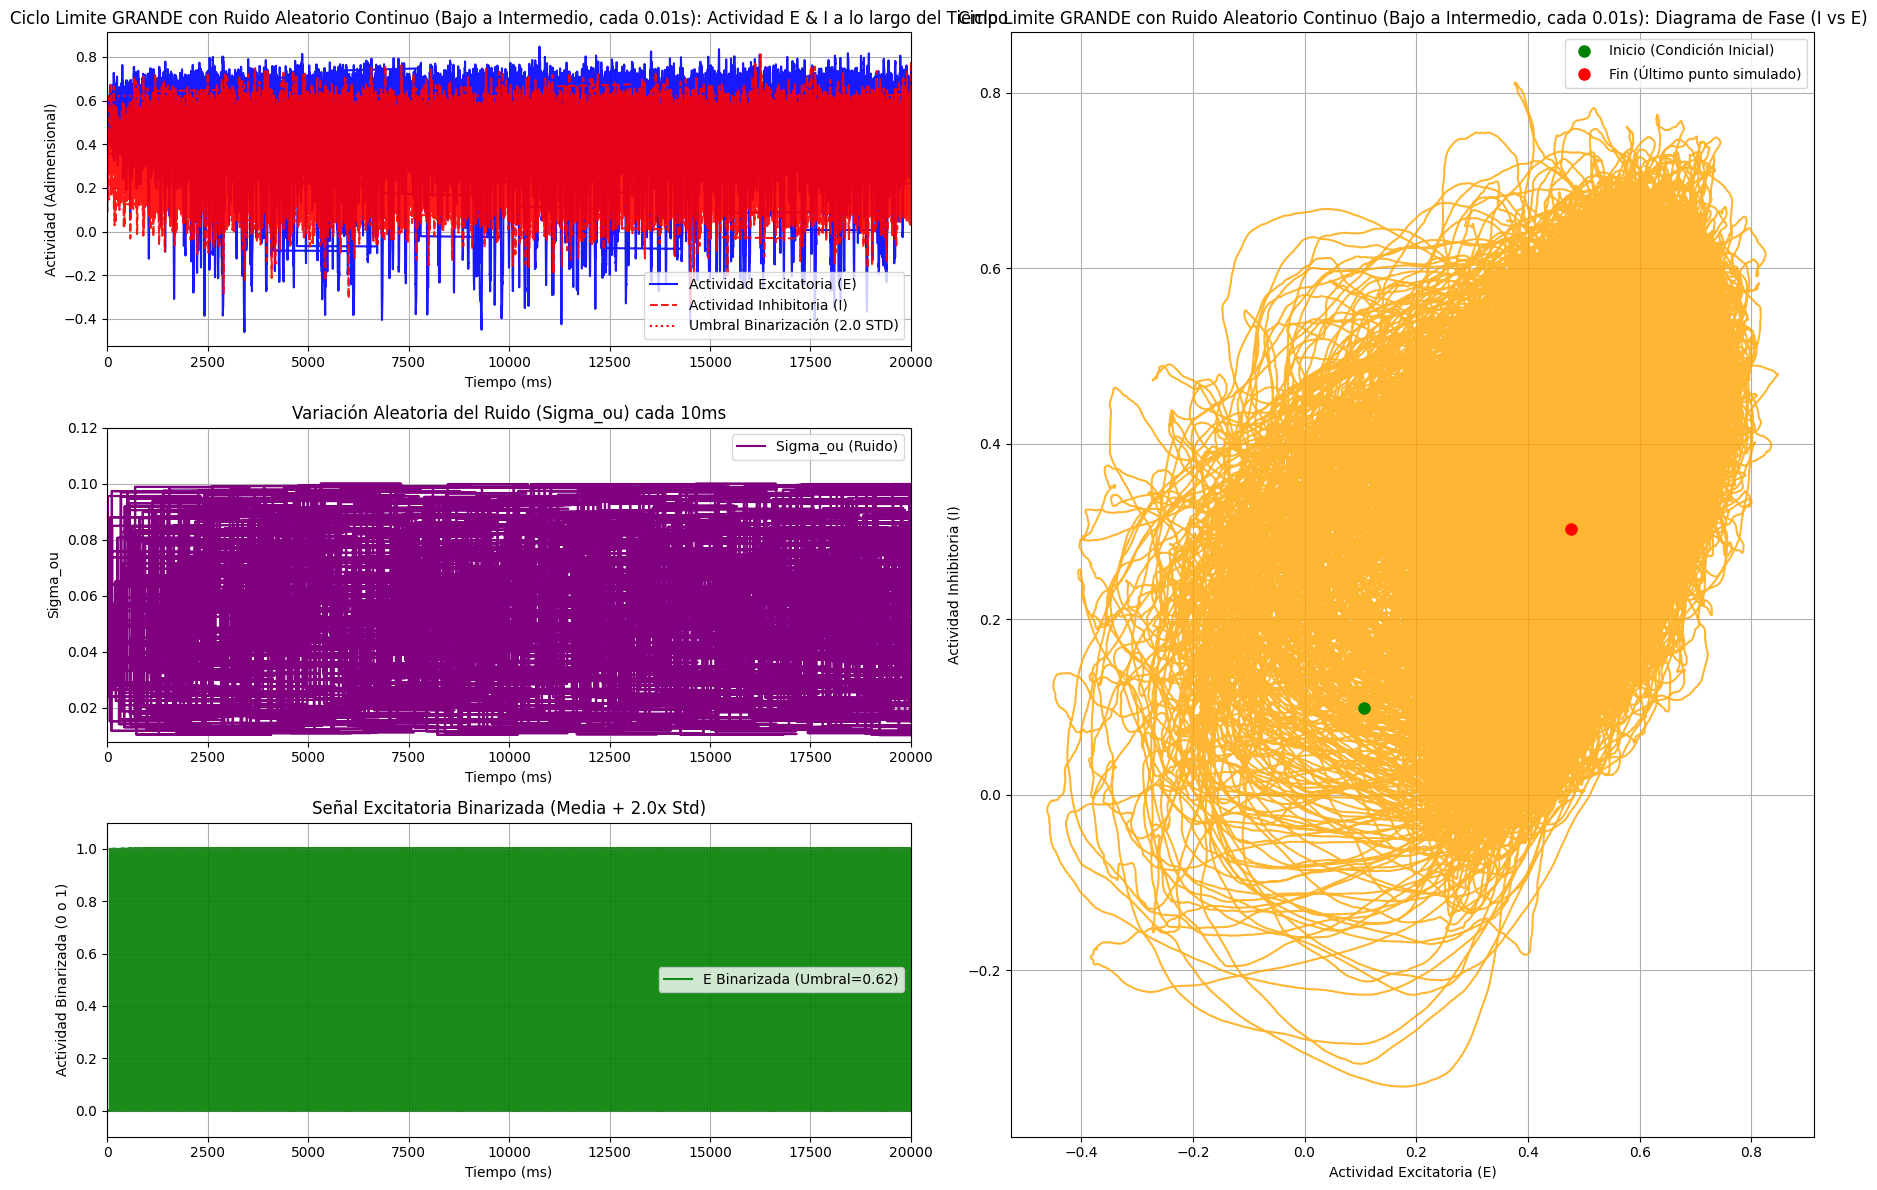

  Ciclo Limite GRANDE con Ruido Aleatorio Continuo (Bajo a Intermedio, cada 0.01s) simulation completed.

--- ¡Ruido Aleatorio Continuo Implementado Cada 10ms! ---
El nivel de ruido (`sigma_ou`) ahora cambia de manera aleatoria en el rango de 0.01 a 0.1 en cada paso de 10ms.
Esto generará una fluctuación del ruido a la máxima resolución de tu paso de tiempo.

**Experimenta con:**
  - Los límites de `min_global_noise` y `max_global_noise` para definir el rango de la aleatoriedad.
  - El `threshold_multiplier` (actualmente 2.0) para ajustar la definición de los 'bursts'.


In [28]:
import neurolib.models.wc as wc
import numpy as np
import matplotlib.pyplot as plt

# --- Configuración de la Simulación ---
duration = 20000  # ms (20 segundos)
dt = 0.1         # ms (Paso de tiempo)

# --- Definición del Rango Global de Ruido Aleatorio (De Bajo a Intermedio) ---
min_global_noise = 0.01  # Valor mínimo para el ruido (considerado 'bajo')
max_global_noise = 0.10  # Valor máximo para el ruido (considerado 'intermedio')

# --- ¡CAMBIO CLAVE AQUÍ! ---
segment_duration_ms = 10 # Duración de cada segmento aleatorio (0.01 segundos)
# --- FIN DEL CAMBIO CLAVE ---

num_segments = int(duration / segment_duration_ms)

# --- Generación Aleatoria del Perfil de Ruido ---
noise_profile_segments = []
current_time = 0.0
np.random.seed(42) # Para reproducibilidad de los resultados aleatorios

print(f"Generando perfil de ruido aleatorio entre {min_global_noise} y {max_global_noise} cada {segment_duration_ms}ms...")

for i in range(num_segments):
    current_time += segment_duration_ms
    
    # Seleccionar un valor aleatorio dentro del rango global definido
    sigma_ou_val = np.random.uniform(min_global_noise, max_global_noise)
    
    noise_profile_segments.append({
        "end_time_ms": current_time, 
        "sigma_ou_val": sigma_ou_val
    })

# --- Definición de Parámetros del Modelo ---
regime_name = "Ciclo Limite GRANDE con Ruido Aleatorio Continuo (Bajo a Intermedio, cada 0.01s)"
params = {
    'exc_ext': 0.72,
    'plot_xlim_start': 0, 
    'plot_xlim_end': duration
}

common_wc_params = {
    'a_exc': 1.0,
    'mu_exc': 0.3,
    'a_inh': 1.0,
    'mu_inh': 4.0,
    'tau_exc': 10.0,
    'tau_inh': 10.0,
    'c_excexc': 16.0,
    'c_excinh': 10.0,
    'c_inhexc': 10.0,
    'c_inhinh': 2.0,
    'tau_ou': 10.0,
    'exc_ou_mean': 0.0,
    'inh_ou_mean': 0.0,
    'exc_init': np.array([[0.1]]),
    'inh_init': np.array([[0.1]])
}

print(f"\n--- Simulating Regime: {regime_name} ---")

# Listas para almacenar los resultados de cada segmento
all_E_signal_segments = []
all_I_signal_segments = []
all_time_segments = []
all_sigma_ou_values_segments = []

current_start_time_ms = 0.0
initial_exc = common_wc_params['exc_init']
initial_inh = common_wc_params['inh_init']

print(f"Iniciando simulación por {num_segments} segmentos de {segment_duration_ms}ms con ruido aleatorio continuo...")

for i, segment in enumerate(noise_profile_segments):
    segment_end_time_ms = segment["end_time_ms"]
    segment_sigma_ou_val = segment["sigma_ou_val"]
    segment_duration_ms_actual = segment_end_time_ms - current_start_time_ms

    # 1. Crear e Instanciar el Modelo para el segmento actual
    segment_model = wc.WCModel()
    segment_model.duration = segment_duration_ms_actual
    segment_model.dt = dt

    # Asignar parámetros comunes y específicos del segmento
    for p_name, p_val in common_wc_params.items():
        segment_model.params[p_name] = p_val
    segment_model.params['exc_ext'] = params['exc_ext']
    segment_model.params['sigma_ou'] = segment_sigma_ou_val 

    # Usar las condiciones finales del segmento anterior como iniciales para el actual
    segment_model.params['exc_init'] = initial_exc
    segment_model.params['inh_init'] = initial_inh

    # 2. Ejecutar la simulación para este segmento
    segment_model.run()

    # 3. Extraer los resultados del segmento y ajustar el tiempo
    if i == 0:
        segment_time = segment_model.outputs["t"]
        segment_E = segment_model.outputs["exc"][0]
        segment_I = segment_model.outputs["inh"][0]
    else:
        segment_time = segment_model.outputs["t"][1:] + current_start_time_ms
        segment_E = segment_model.outputs["exc"][0][1:]
        segment_I = segment_model.outputs["inh"][0][1:]

    all_time_segments.append(segment_time)
    all_E_signal_segments.append(segment_E)
    all_I_signal_segments.append(segment_I)
    all_sigma_ou_values_segments.append(np.full_like(segment_time, segment_sigma_ou_val))

    # Actualizar las condiciones iniciales para el próximo segmento
    initial_exc = segment_model.exc
    initial_inh = segment_model.inh
    current_start_time_ms = segment_end_time_ms

print("Simulación por segmentos con ruido aleatorio continuo completada.")

# --- 4. Concatenar todas las señales ---
time = np.concatenate(all_time_segments)
E_signal = np.concatenate(all_E_signal_segments)
I_signal = np.concatenate(all_I_signal_segments)
all_sigma_ou_values = np.concatenate(all_sigma_ou_values_segments)

# --- Binarización de la señal E: Umbral = Media + 2 * Desviación Estándar (desde 0 segundos) ---
start_time_for_stats_ms = 0 
start_idx_for_stats = int(start_time_for_stats_ms / dt)

stable_E_signal_for_stats = E_signal[start_idx_for_stats:]

mean_E_from_stats_segment = np.mean(stable_E_signal_for_stats)
std_E_from_stats_segment = np.std(stable_E_signal_for_stats)

threshold_multiplier = 2.0 
threshold_E_binarization = mean_E_from_stats_segment + threshold_multiplier * std_E_from_stats_segment

E_signal_binarized = (E_signal > threshold_E_binarization).astype(int)

# --- DEPURACIÓN: Verificar formas, primeros/últimos valores, y rango ---
print(f"Forma de t (total): {time.shape}")
print(f"Forma de E_signal (total): {E_signal.shape}")
print(f"Forma de I_signal (total): {I_signal.shape}")
print(f"Forma de E_signal_binarized: {E_signal_binarized.shape}")
print(f"Min/Max/Mean de E_signal: {np.min(E_signal):.4f} / {np.max(E_signal):.4f} / {np.mean(E_signal):.4f}")
print(f"Media de E_signal (desde {start_time_for_stats_ms} ms): {mean_E_from_stats_segment:.4f}")
print(f"Desviación estándar de E_signal (desde {start_time_for_stats_ms} ms): {std_E_from_stats_segment:.4f}")
print(f"Umbral de Binarización (Media + {threshold_multiplier}x Std desde {start_time_for_stats_ms} ms): {threshold_E_binarization:.4f}")
print(f"Min/Max de E_signal_binarized: {np.min(E_signal_binarized)} / {np.max(E_signal_binarized)}")
print(f"Min/Max/Mean de I_signal: {np.min(I_signal):.4f} / {np.max(I_signal):.4f} / {np.mean(I_signal):.4f}")


# --- 5. Plotear las señales E e I a lo largo del tiempo y el Diagrama de Fase ---
plt.figure(figsize=(18, 12))

# Subplot 1: Actividad Excitatoria e Inhibitoria en el Tiempo
plt.subplot(3, 2, 1)
plt.plot(time, E_signal, label='Actividad Excitatoria (E)', color='blue', alpha=0.9)
plt.plot(time, I_signal, label='Actividad Inhibitoria (I)', color='red', linestyle='--', alpha=0.9)
plt.axhline(y=threshold_E_binarization, color='r', linestyle=':', label=f"Umbral Binarización ({threshold_multiplier} STD)")
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad (Adimensional)')
plt.title(f'{regime_name}: Actividad E & I a lo largo del Tiempo')
plt.legend()
plt.grid(True)
plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])

# Subplot 2: Valores de Sigma_ou a lo largo del Tiempo
plt.subplot(3, 2, 3)
plt.plot(time, all_sigma_ou_values, label='Sigma_ou (Ruido)', color='purple', drawstyle='steps-post')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Sigma_ou')
plt.title(f'Variación Aleatoria del Ruido (Sigma_ou) cada {segment_duration_ms}ms')
plt.legend()
plt.grid(True)
plt.ylim(min_global_noise * 0.8, max_global_noise * 1.2)
plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])

# Subplot 3: Señal Excitatoria Binarizada en el Tiempo
plt.subplot(3, 2, 5)
plt.plot(time, E_signal_binarized, label=f'E Binarizada (Umbral={threshold_E_binarization:.2f})', color='green', alpha=0.9, drawstyle='steps-post')
plt.axhline(y=1, color='gray', linestyle=':', linewidth=0.8)
plt.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
plt.xlabel('Tiempo (ms)')
plt.ylabel('Actividad Binarizada (0 o 1)')
plt.title(f'Señal Excitatoria Binarizada (Media + {threshold_multiplier}x Std)')
plt.legend()
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.xlim(params['plot_xlim_start'], params['plot_xlim_end'])


# Subplot 4: Diagrama de Fase (I vs E)
plt.subplot(1, 2, 2)
plt.plot(E_signal, I_signal, color='orange', linewidth=1.5, alpha=0.8)

plt.plot(E_signal[0], I_signal[0], 'go', markersize=8, label='Inicio (Condición Inicial)')
plt.plot(E_signal[-1], I_signal[-1], 'ro', markersize=8, label='Fin (Último punto simulado)')

plt.xlabel('Actividad Excitatoria (E)')
plt.ylabel('Actividad Inhibitoria (I)')
plt.title(f'{regime_name}: Diagrama de Fase (I vs E)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"  {regime_name} simulation completed.")
print(f"\n--- ¡Ruido Aleatorio Continuo Implementado Cada {segment_duration_ms}ms! ---")
print(f"El nivel de ruido (`sigma_ou`) ahora cambia de manera aleatoria en el rango de {min_global_noise} a {max_global_noise} en cada paso de {segment_duration_ms}ms.")
print("Esto generará una fluctuación del ruido a la máxima resolución de tu paso de tiempo.")
print("\n**Experimenta con:**")
print("  - Los límites de `min_global_noise` y `max_global_noise` para definir el rango de la aleatoriedad.")
print("  - El `threshold_multiplier` (actualmente 2.0) para ajustar la definición de los 'bursts'.")